In [4]:
import yfinance as yf
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt



In [18]:
# Load Excel file containing ticker symbols
# The Excel file should have a column named 'Ticker'
tickers_df = pd.read_excel('stocks.xlsx')
tickers = tickers_df['Ticker'].tolist()



In [39]:
# Function to analyze a single stock
def analyze_stock(ticker):
    # Pull 6 months of daily stock data
    stock_data = yf.download(ticker, period='6mo', interval='1d')
    
    if stock_data.empty:
        print(f"No data found for {ticker}")
        return
    
    # Use closing price for regression
    stock_data['Day'] = range(1, len(stock_data) + 1)
    X = sm.add_constant(stock_data['Day'])  # Independent variable
    y = stock_data['Close']  # Dependent variable (price)
    
    # Fit regression model
    model = sm.OLS(y, X).fit()
    
    # Predict the next day price
    next_day = len(stock_data) + 1
    predicted_price = float(model.predict([1, next_day])[0])
    current_price = float(stock_data['Close'].iloc[-1])
    
    print(f"\n=== {ticker} ===")
    print(model.summary())
    print(f"Current Price: {current_price:.2f}")
    print(f"Predicted Price (next day): {predicted_price:.2f}")
    
    # Decide whether to plot / recommend
    if model.params[1] > 0 and predicted_price > current_price:
        print(f"Recommendation: Consider buying {ticker}")
        
        # Plot
        plt.figure(figsize=(10,5))
        plt.plot(stock_data.index, stock_data['Close'], label='Actual Price')
        plt.plot(stock_data.index, model.predict(X), label='Regression Line', color='red')
        plt.title(f"{ticker} Price vs Regression")
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.legend()
        plt.show()
    else:
        print(f"Recommendation: No buy signal for {ticker}")



[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== AREXMIS.BO ===
                            OLS Regression Results                            
Dep. Variable:             AREXMIS.BO   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     64.78
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           4.85e-12
Time:                        10:37:45   Log-Likelihood:                -245.47
No. Observations:                  86   AIC:                             494.9
Df Residuals:                      84   BIC:                             499.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        159.1026      0.925

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== DBCORP.BO ===
                            OLS Regression Results                            
Dep. Variable:              DBCORP.BO   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     30.38
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.92e-07
Time:                        10:37:46   Log-Likelihood:                -509.57
No. Observations:                 128   AIC:                             1023.
Df Residuals:                     126   BIC:                             1029.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        251.8678      2.323 

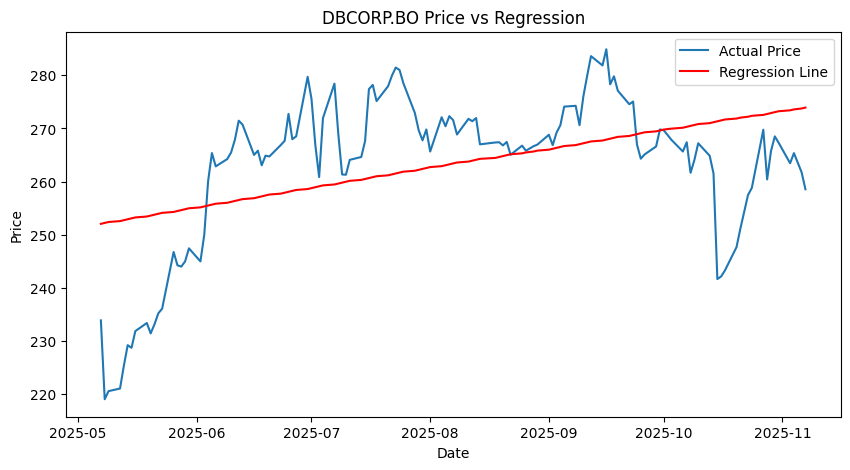

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== BHEL.BO ===
                            OLS Regression Results                            
Dep. Variable:                BHEL.BO   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     13.38
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           0.000373
Time:                        10:37:46   Log-Likelihood:                -527.81
No. Observations:                 128   AIC:                             1060.
Df Residuals:                     126   BIC:                             1065.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        249.9152      2.679   

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== IRB.BO ===
                            OLS Regression Results                            
Dep. Variable:                 IRB.BO   R-squared:                       0.689
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     278.9
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           9.71e-34
Time:                        10:37:47   Log-Likelihood:                -260.10
No. Observations:                 128   AIC:                             524.2
Df Residuals:                     126   BIC:                             529.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.0082      0.331    

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


...

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TATAMTRDVR.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SUPDF.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for TATAMTRDVR.BO
No data found for SUPDF.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== SHRIDINE.BO ===
                            OLS Regression Results                            
Dep. Variable:            SHRIDINE.BO   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     484.7
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           5.23e-45
Time:                        10:37:51   Log-Likelihood:                -450.06
No. Observations:                 128   AIC:                             904.1
Df Residuals:                     126   BIC:                             909.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        328.3790      1.45

/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


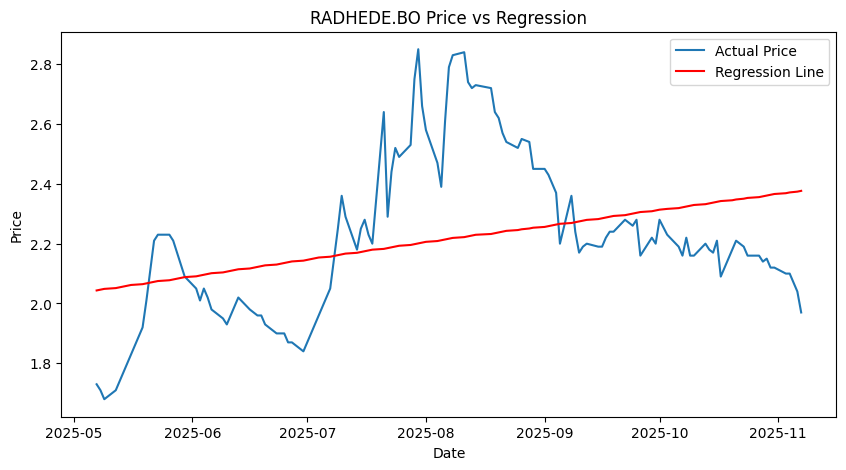

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['PROTODEV.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for PROTODEV.BO

=== NDMETAL.BO ===
                            OLS Regression Results                            
Dep. Variable:             NDMETAL.BO   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     441.3
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           3.81e-43
Time:                        10:37:51   Log-Likelihood:                -209.72
No. Observations:                 129   AIC:                             423.4
Df Residuals:                     127   BIC:                             429.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['MDRNSUT-B.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for MDRNSUT-B.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== MANGALAM.BO ===
                            OLS Regression Results                            
Dep. Variable:            MANGALAM.BO   R-squared:                       0.392
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     81.27
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.69e-15
Time:                        10:37:52   Log-Likelihood:                -396.42
No. Observations:                 128   AIC:                             796.8
Df Residuals:                     126   BIC:                             802.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         85.9002      0.96

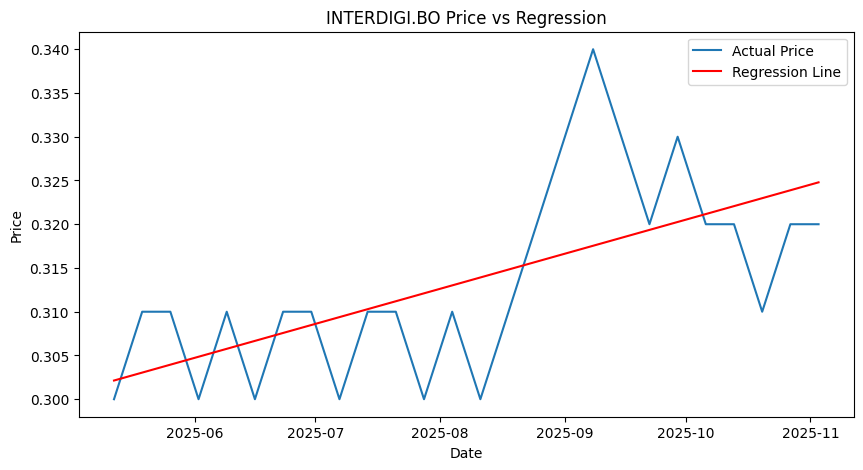

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== INDTONER.BO ===
                            OLS Regression Results                            
Dep. Variable:            INDTONER.BO   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     85.12
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           8.33e-16
Time:                        10:37:53   Log-Likelihood:                -376.03
No. Observations:                 128   AIC:                             756.1
Df Residuals:                     126   BIC:                             761.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        256.6522      0.81

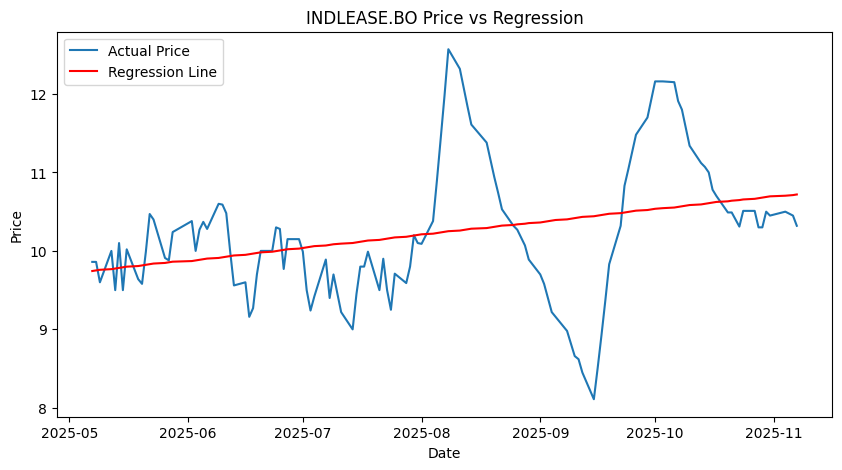

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== HDIL.BO ===
                            OLS Regression Results                            
Dep. Variable:                HDIL.BO   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     99.62
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.05e-15
Time:                        10:37:53   Log-Likelihood:                 32.758
No. Observations:                  82   AIC:                            -61.52
Df Residuals:                      80   BIC:                            -56.70
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4047      0.037   

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['HDFC.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])


No data found for HDFC.BO

=== GOLKUNDIA.BO ===


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


...

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ESSDEE.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for ESSDEE.BO


[*********************100%***********************]  1 of 1 completed


=== EIDPARRY.BO ===
                            OLS Regression Results                            
Dep. Variable:            EIDPARRY.BO   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     24.13
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.73e-06
Time:                        10:37:55   Log-Likelihood:                -739.42
No. Observations:                 128   AIC:                             1483.
Df Residuals:                     126   BIC:                             1489.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1003.1692     13.99


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


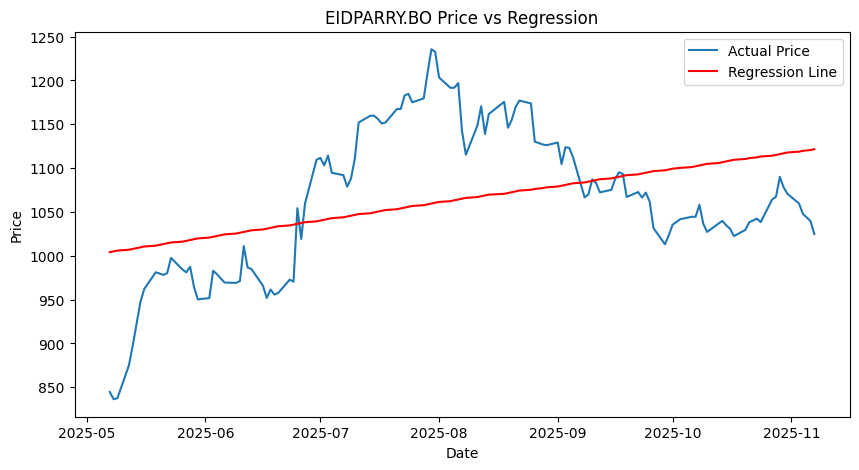

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== KELENRG.BO ===
                            OLS Regression Results                            
Dep. Variable:             KELENRG.BO   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.178
Method:                 Least Squares   F-statistic:                     28.57
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           4.09e-07
Time:                        10:37:55   Log-Likelihood:                -897.54
No. Observations:                 128   AIC:                             1799.
Df Residuals:                     126   BIC:                             1805.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3879.4069     48.133

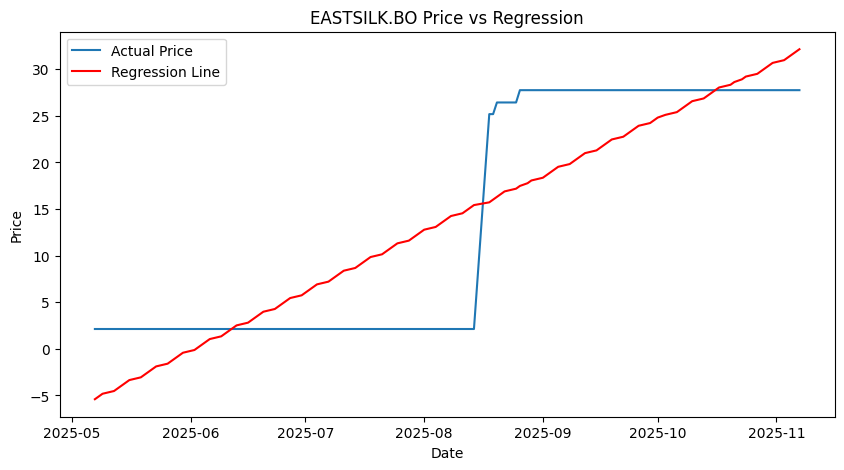

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['STEERINTER.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SEQUELE.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for STEERINTER.BO
No data found for SEQUELE.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== MKEXIM.BO ===
                            OLS Regression Results                            
Dep. Variable:              MKEXIM.BO   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                   0.07701
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.782
Time:                        10:37:56   Log-Likelihood:                -427.46
No. Observations:                 128   AIC:                             858.9
Df Residuals:                     126   BIC:                             864.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         68.2942      1.223 

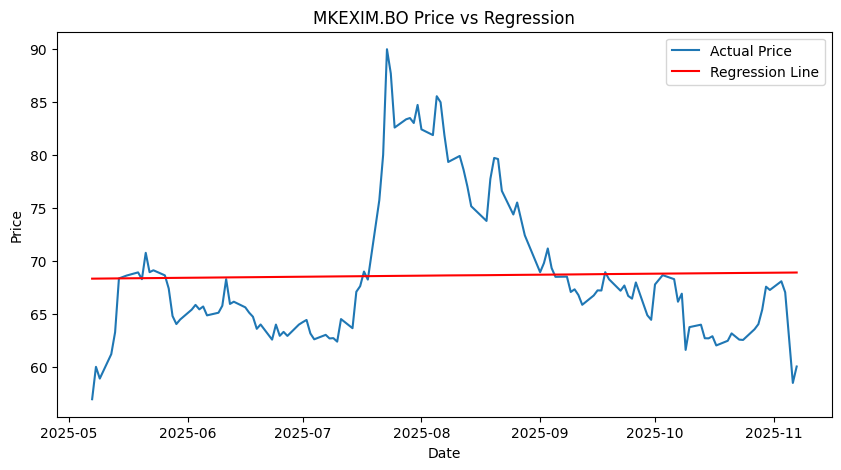

[*********************100%***********************]  1 of 1 completed


=== JAYTEX.BO ===
                            OLS Regression Results                            
Dep. Variable:              JAYTEX.BO   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     608.3
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.89e-50
Time:                        10:37:56   Log-Likelihood:                 55.420
No. Observations:                 129   AIC:                            -106.8
Df Residuals:                     127   BIC:                            -101.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.8638      0.028 


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


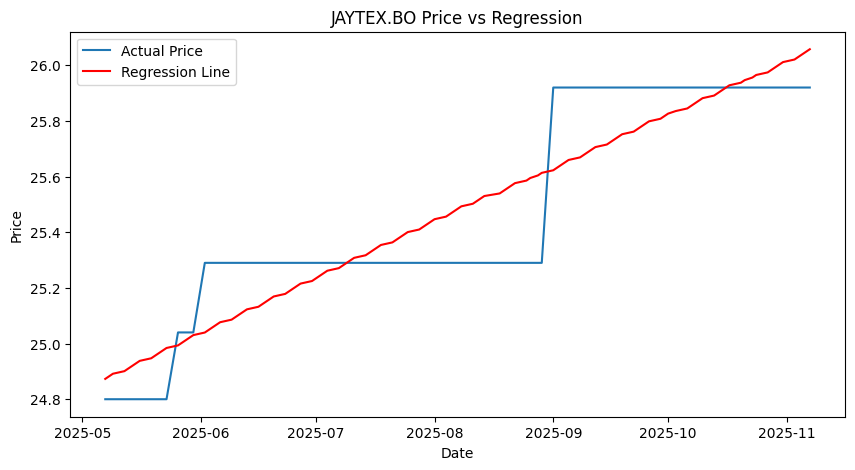

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['IBREALEST.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for IBREALEST.BO

=== EMMESSA.BO ===
                            OLS Regression Results                            
Dep. Variable:             EMMESSA.BO   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     19.24
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.42e-05
Time:                        10:37:57   Log-Likelihood:                -304.32
No. Observations:                 127   AIC:                             612.6
Df Residuals:                     125   BIC:                             618.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ECOM.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for ECOM.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


...

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== SUNDARMFIN.BO ===
                            OLS Regression Results                            
Dep. Variable:          SUNDARMFIN.BO   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     151.4
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.45e-23
Time:                        10:38:00   Log-Likelihood:                -852.22
No. Observations:                 128   AIC:                             1708.
Df Residuals:                     126   BIC:                             1714.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5164.9608     33.

[*********************100%***********************]  1 of 1 completed


=== RELAXO.BO ===
                            OLS Regression Results                            
Dep. Variable:              RELAXO.BO   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     7.099
Date:                Sun, 09 Nov 2025   Prob (F-statistic):            0.00872
Time:                        10:38:00   Log-Likelihood:                -606.18
No. Observations:                 128   AIC:                             1216.
Df Residuals:                     126   BIC:                             1222.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        439.8061      4.942 


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


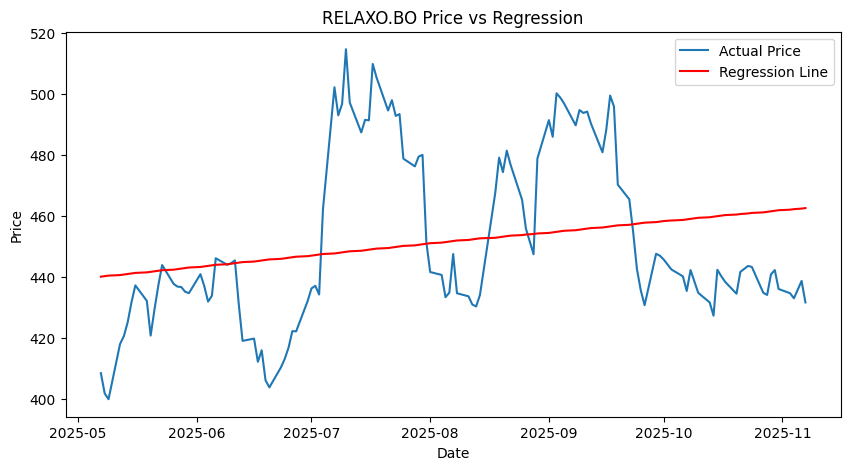

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== RCF.BO ===
                            OLS Regression Results                            
Dep. Variable:                 RCF.BO   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     2.906
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0907
Time:                        10:38:00   Log-Likelihood:                -391.41
No. Observations:                 128   AIC:                             786.8
Df Residuals:                     126   BIC:                             792.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.2912      0.923    

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== KZLFIN.BO ===
                            OLS Regression Results                            
Dep. Variable:              KZLFIN.BO   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     7.444
Date:                Sun, 09 Nov 2025   Prob (F-statistic):            0.00736
Time:                        10:38:01   Log-Likelihood:                -273.99
No. Observations:                 118   AIC:                             552.0
Df Residuals:                     116   BIC:                             557.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.0070      0.461 

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['IFSL.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


...

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['GEEFC.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for GEEFC.BO


[*********************100%***********************]  1 of 1 completed


=== FORCEMOT.BO ===
                            OLS Regression Results                            
Dep. Variable:            FORCEMOT.BO   R-squared:                       0.562
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     161.5
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.53e-24
Time:                        10:38:03   Log-Likelihood:                -1151.7
No. Observations:                 128   AIC:                             2307.
Df Residuals:                     126   BIC:                             2313.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.209e+04    350.50


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


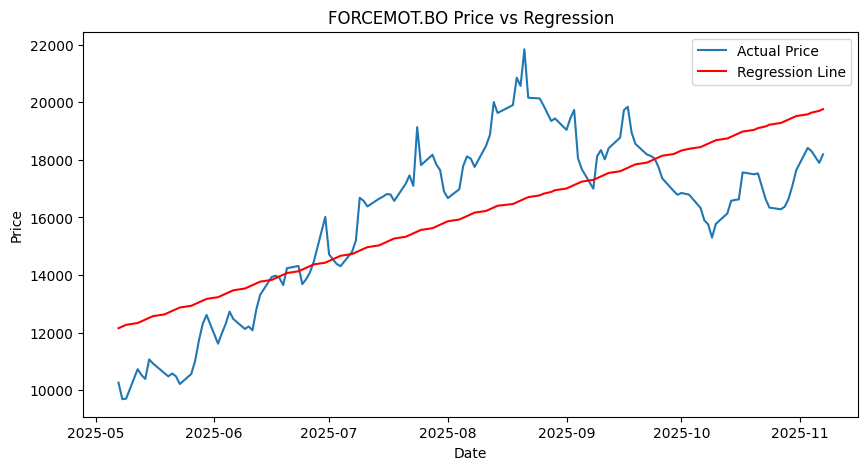

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== FOODSIN.BO ===
                            OLS Regression Results                            
Dep. Variable:             FOODSIN.BO   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     61.04
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.04e-12
Time:                        10:38:03   Log-Likelihood:                -452.06
No. Observations:                 126   AIC:                             908.1
Df Residuals:                     124   BIC:                             913.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        107.0147      1.581

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


=== FFPL.BO ===
                            OLS Regression Results                            
Dep. Variable:                FFPL.BO   R-squared:                       0.142
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     2.484
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.136
Time:                        10:38:03   Log-Likelihood:                -1.3160
No. Observations:                  17   AIC:                             6.632
Df Residuals:                      15   BIC:                             8.298
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.2493      0.141   

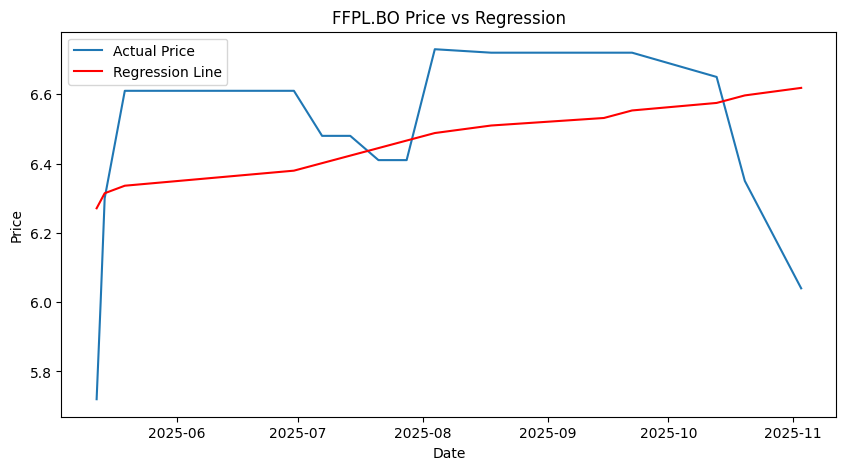

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ARORAFIB.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for ARORAFIB.BO

=== AJWAFUN.BO ===
                            OLS Regression Results                            
Dep. Variable:             AJWAFUN.BO   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.016
Method:                 Least Squares   F-statistic:                  0.001527
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.969
Time:                        10:38:04   Log-Likelihood:                -229.08
No. Observations:                  63   AIC:                             462.2
Df Residuals:                      61   BIC:                             466.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== ADMANUM.BO ===
                            OLS Regression Results                            
Dep. Variable:             ADMANUM.BO   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     103.0
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           5.05e-18
Time:                        10:38:04   Log-Likelihood:                -293.64
No. Observations:                 127   AIC:                             591.3
Df Residuals:                     125   BIC:                             597.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.4043      0.440

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ZSUBWAYF.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ZSIYARPO.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


...

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['WEIZFOREX.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed


No data found for WEIZFOREX.BO


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])



=== WALLFORT.BO ===
                            OLS Regression Results                            
Dep. Variable:            WALLFORT.BO   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     5.108
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0255
Time:                        10:38:08   Log-Likelihood:                -401.65
No. Observations:                 128   AIC:                             807.3
Df Residuals:                     126   BIC:                             813.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        116.6613      1.00

/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


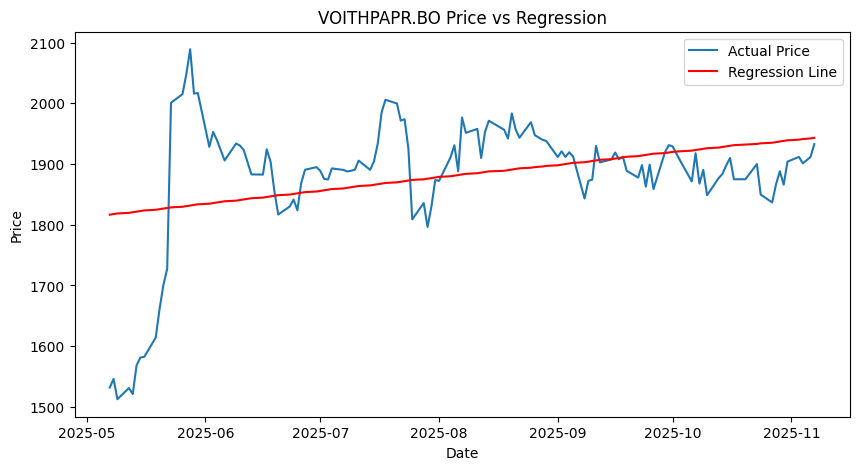

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['VBCFERROQ.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer ke

No data found for VBCFERROQ.BO

=== VAXHS.BO ===
                            OLS Regression Results                            
Dep. Variable:               VAXHS.BO   R-squared:                        -inf
Model:                            OLS   Adj. R-squared:                   -inf
Method:                 Least Squares   F-statistic:                    -127.0
Date:                Sun, 09 Nov 2025   Prob (F-statistic):               1.00
Time:                        10:38:09   Log-Likelihood:                 4325.4
No. Observations:                 129   AIC:                            -8647.
Df Residuals:                     127   BIC:                            -8641.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['UPASAFN.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TIRFOAM.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for UPASAFN.BO
No data found for TIRFOAM.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== GAYAPROJ.BO ===
                            OLS Regression Results                            
Dep. Variable:            GAYAPROJ.BO   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     41.46
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           8.65e-09
Time:                        10:38:10   Log-Likelihood:                -91.565
No. Observations:                  81   AIC:                             187.1
Df Residuals:                      79   BIC:                             191.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.8108      0.17

[*********************100%***********************]  1 of 1 completed


=== TAJGVK.BO ===
                            OLS Regression Results                            
Dep. Variable:              TAJGVK.BO   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     4.667
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0326
Time:                        10:38:10   Log-Likelihood:                -547.76
No. Observations:                 128   AIC:                             1100.
Df Residuals:                     126   BIC:                             1105.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        411.5693      3.131 


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


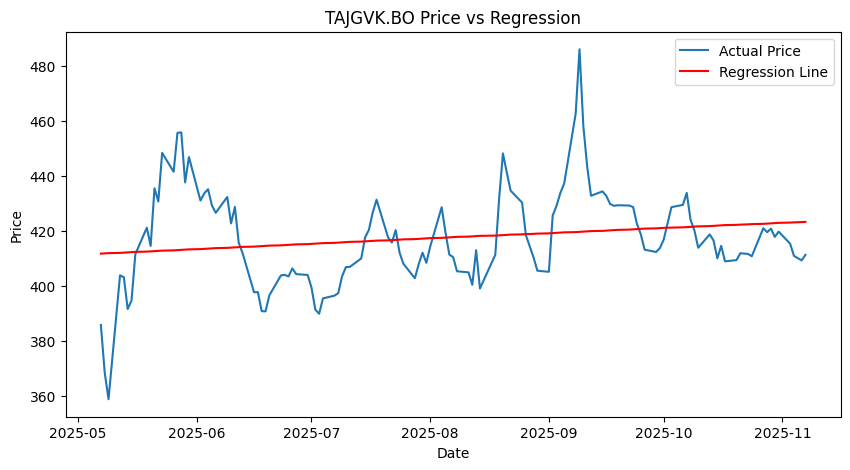

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== ONGC.BO ===
                            OLS Regression Results                            
Dep. Variable:                ONGC.BO   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     2.513
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.115
Time:                        10:38:10   Log-Likelihood:                -414.90
No. Observations:                 128   AIC:                             833.8
Df Residuals:                     126   BIC:                             839.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        240.0923      1.109   

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['PAPERPROD.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])


No data found for PAPERPROD.BO

=== ITHL.BO ===


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


                            OLS Regression Results                            
Dep. Variable:                ITHL.BO   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     81.62
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.42e-15
Time:                        10:38:11   Log-Likelihood:                -517.17
No. Observations:                 128   AIC:                             1038.
Df Residuals:                     126   BIC:                             1044.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        506.4051      2.465    205.410      0.0

[*********************100%***********************]  1 of 1 completed


=== HESTERBIO.BO ===
                            OLS Regression Results                            
Dep. Variable:           HESTERBIO.BO   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.1958
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.659
Time:                        10:38:11   Log-Likelihood:                -811.96
No. Observations:                 128   AIC:                             1628.
Df Residuals:                     126   BIC:                             1634.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1849.2157     24.6


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


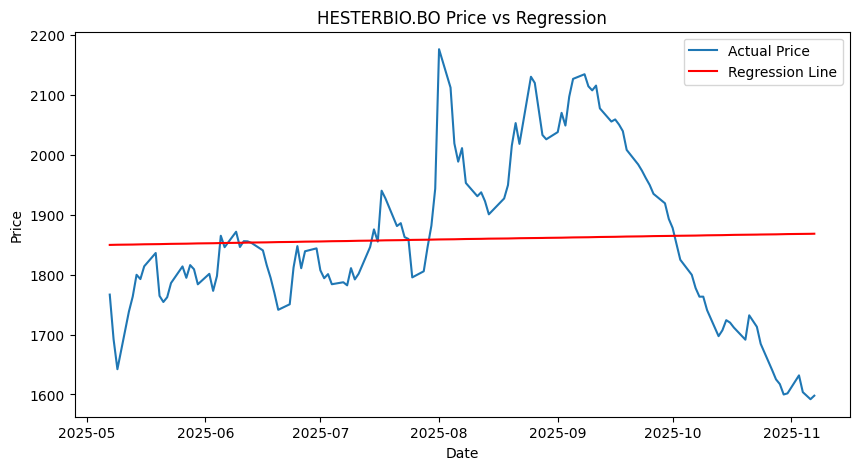

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== HCC.BO ===
                            OLS Regression Results                            
Dep. Variable:                 HCC.BO   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     28.36
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           4.47e-07
Time:                        10:38:12   Log-Likelihood:                -284.13
No. Observations:                 128   AIC:                             572.3
Df Residuals:                     126   BIC:                             578.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.5917      0.399    

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed


=== GRAVISSHO.BO ===
                            OLS Regression Results                            
Dep. Variable:           GRAVISSHO.BO   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     87.81
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           3.73e-16
Time:                        10:38:12   Log-Likelihood:                -256.02
No. Observations:                 128   AIC:                             516.0
Df Residuals:                     126   BIC:                             521.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         45.3619      0.3


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


...

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SGJHL.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')



=== SHHARICH.BO ===
                            OLS Regression Results                            
Dep. Variable:            SHHARICH.BO   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     865.8
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.69e-58
Time:                        10:38:15   Log-Likelihood:                -440.55
No. Observations:                 128   AIC:                             885.1
Df Residuals:                     126   BIC:                             890.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        156.3932      1.35

[*********************100%***********************]  1 of 1 completed


=== ROHLTD.BO ===
                            OLS Regression Results                            
Dep. Variable:              ROHLTD.BO   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     366.9
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           3.92e-39
Time:                        10:38:16   Log-Likelihood:                -626.99
No. Observations:                 128   AIC:                             1258.
Df Residuals:                     126   BIC:                             1264.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        342.4953      5.814 


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


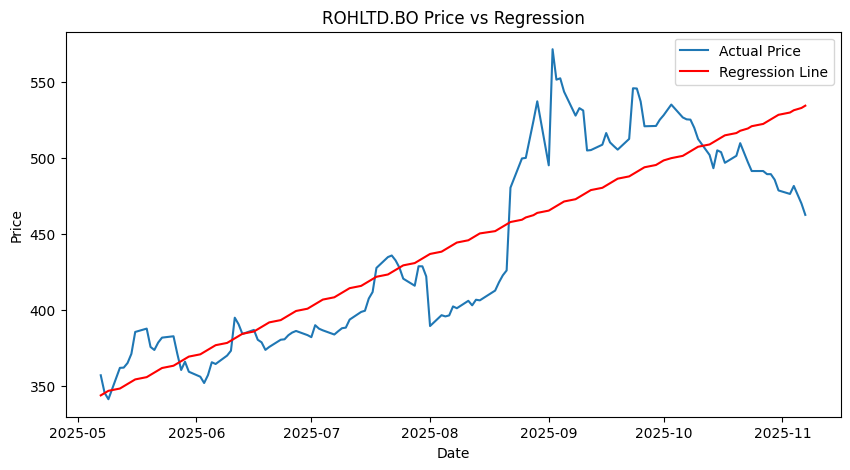

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== JKIL.BO ===
                            OLS Regression Results                            
Dep. Variable:                JKIL.BO   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     138.7
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           4.72e-22
Time:                        10:38:16   Log-Likelihood:                -609.30
No. Observations:                 128   AIC:                             1223.
Df Residuals:                     126   BIC:                             1228.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        727.4995      5.064   

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JVLAGRO.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed

No data found for JVLAGRO.BO

=== JAIBALAJI.BO ===



/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SBBJ.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


...

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== JSWSTEEL.BO ===
                            OLS Regression Results                            
Dep. Variable:            JSWSTEEL.BO   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     867.1
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.46e-58
Time:                        10:38:17   Log-Likelihood:                -584.35
No. Observations:                 128   AIC:                             1173.
Df Residuals:                     126   BIC:                             1178.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        958.2160      4.16

[*********************100%***********************]  1 of 1 completed


=== JSWENERGY.BO ===
                            OLS Regression Results                            
Dep. Variable:           JSWENERGY.BO   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.460
Method:                 Least Squares   F-statistic:                     109.1
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           8.80e-19
Time:                        10:38:18   Log-Likelihood:                -519.10
No. Observations:                 128   AIC:                             1042.
Df Residuals:                     126   BIC:                             1048.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        496.4278      2.5


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


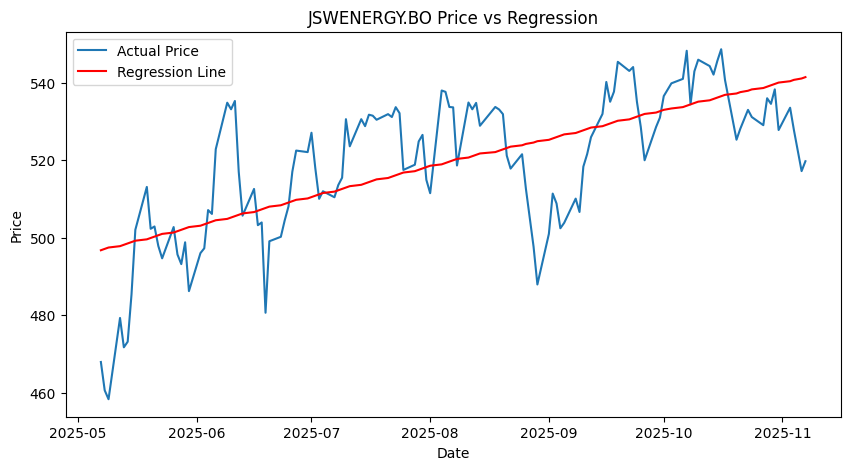

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== JPTSEC.BO ===
                            OLS Regression Results                            
Dep. Variable:              JPTSEC.BO   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     116.3
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.10e-10
Time:                        10:38:18   Log-Likelihood:                -40.414
No. Observations:                  26   AIC:                             84.83
Df Residuals:                      24   BIC:                             87.34
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.0609      0.481 

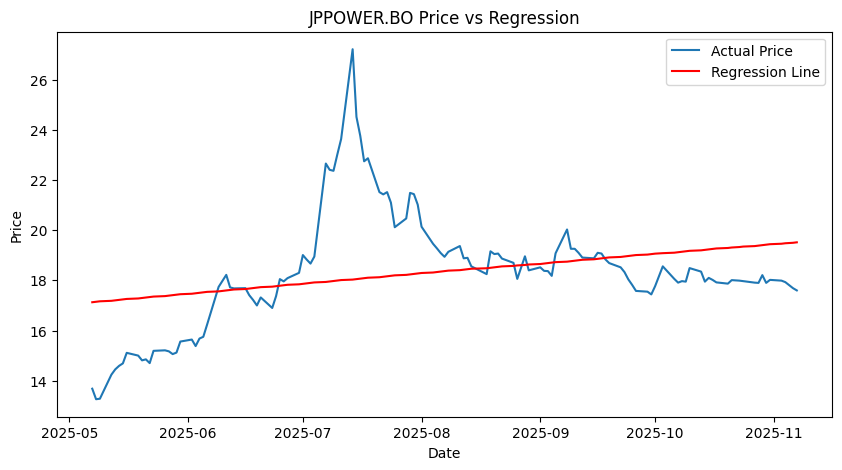

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JPINFRATEC.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for JPINFRATEC.BO

=== JETKINGQ.BO ===
                            OLS Regression Results                            
Dep. Variable:            JETKINGQ.BO   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     23.46
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           3.67e-06
Time:                        10:38:18   Log-Likelihood:                -729.15
No. Observations:                 128   AIC:                             1462.
Df Residuals:                     126   BIC:                             1468.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

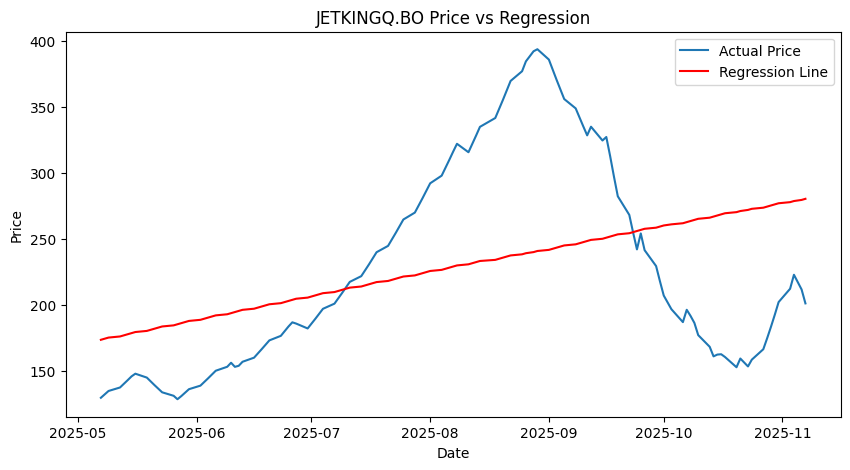

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/stats/stattools.py:125: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew = stats.skew(resids, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/stats/stattools.py:126: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis = 3 + stats.kurtosis(resids, 


=== JETAIRWAYS.BO ===
                            OLS Regression Results                            
Dep. Variable:          JETAIRWAYS.BO   R-squared:                        -inf
Model:                            OLS   Adj. R-squared:                   -inf
Method:                 Least Squares   F-statistic:                    -127.0
Date:                Sun, 09 Nov 2025   Prob (F-statistic):               1.00
Time:                        10:38:19   Log-Likelihood:                 3930.1
No. Observations:                 129   AIC:                            -7856.
Df Residuals:                     127   BIC:                            -7850.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.0400   2.54e

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== JAMESWARREN.BO ===
                            OLS Regression Results                            
Dep. Variable:         JAMESWARREN.BO   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                     37.51
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.07e-08
Time:                        10:38:19   Log-Likelihood:                -526.92
No. Observations:                 128   AIC:                             1058.
Df Residuals:                     126   BIC:                             1064.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        329.9632      2

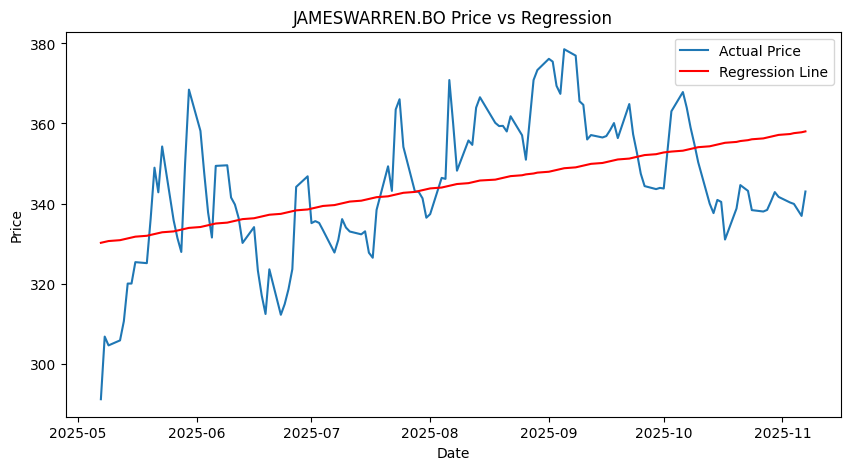

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== JAGSONFI.BO ===
                            OLS Regression Results                            
Dep. Variable:            JAGSONFI.BO   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     18.60
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           3.28e-05
Time:                        10:38:19   Log-Likelihood:                -444.10
No. Observations:                 125   AIC:                             892.2
Df Residuals:                     123   BIC:                             897.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.2582      1.53

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['DIVYAJYQ.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for DIVYAJYQ.BO


[*********************100%***********************]  1 of 1 completed


=== BJDUP.BO ===
                            OLS Regression Results                            
Dep. Variable:               BJDUP.BO   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     1308.
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           9.98e-69
Time:                        10:38:20   Log-Likelihood:                -10.591
No. Observations:                 129   AIC:                             25.18
Df Residuals:                     127   BIC:                             30.90
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.1955      0.047  


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


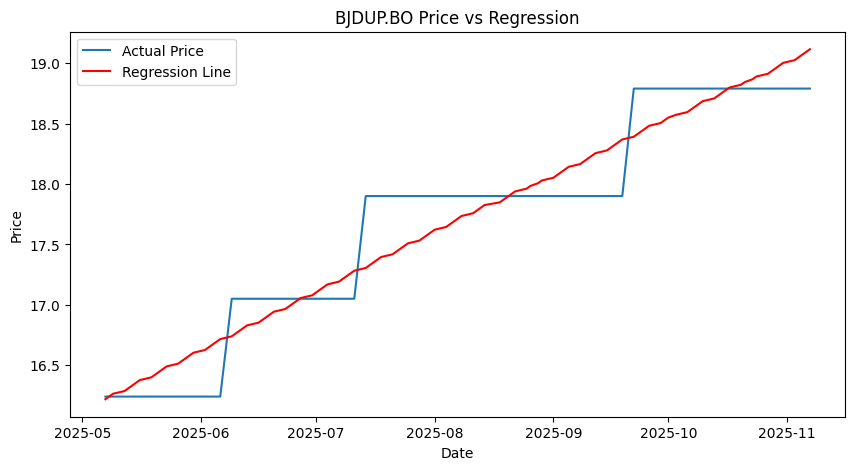

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JAIMI.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for JAIMI.BO

=== JYOTIRES.BO ===
                            OLS Regression Results                            
Dep. Variable:            JYOTIRES.BO   R-squared:                       0.414
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     89.02
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.60e-16
Time:                        10:38:21   Log-Likelihood:                -669.84
No. Observations:                 128   AIC:                             1344.
Df Residuals:                     126   BIC:                             1349.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== JUPITERIN.BO ===
                            OLS Regression Results                            
Dep. Variable:           JUPITERIN.BO   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.306
Method:                 Least Squares   F-statistic:                     57.13
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           7.36e-12
Time:                        10:38:21   Log-Likelihood:                -332.97
No. Observations:                 128   AIC:                             669.9
Df Residuals:                     126   BIC:                             675.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         54.9502      0.5

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JENSONICOL.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for JENSONICOL.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JKLAKBBPH.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JARITEX.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for JKLAKBBPH.BO
No data found for JARITEX.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JAYENGY.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for JAYENGY.BO

=== JAYATMA.BO ===
                            OLS Regression Results                            
Dep. Variable:             JAYATMA.BO   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     9.288
Date:                Sun, 09 Nov 2025   Prob (F-statistic):            0.00281
Time:                        10:38:23   Log-Likelihood:                 125.23
No. Observations:                 129   AIC:                            -246.5
Df Residuals:                     127   BIC:                            -240.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

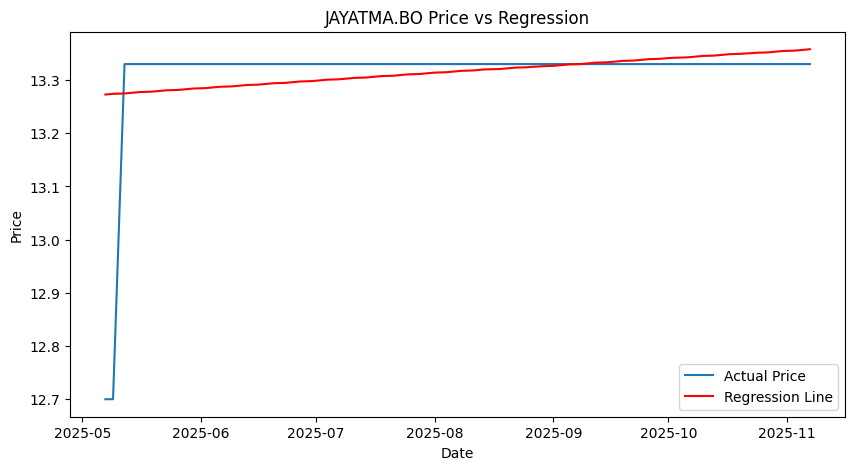

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JAYAMEL.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for JAYAMEL.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['RJBIOTECH.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed

No data found for RJBIOTECH.BO



/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


...

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== JINDALPOLY.BO ===
                            OLS Regression Results                            
Dep. Variable:          JINDALPOLY.BO   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.439
Method:                 Least Squares   F-statistic:                     100.6
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           9.27e-18
Time:                        10:38:25   Log-Likelihood:                -612.17
No. Observations:                 128   AIC:                             1228.
Df Residuals:                     126   BIC:                             1234.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        633.3135      5.

[*********************100%***********************]  1 of 1 completed


=== JPASSOCIAT.BO ===
                            OLS Regression Results                            
Dep. Variable:          JPASSOCIAT.BO   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     9.805
Date:                Sun, 09 Nov 2025   Prob (F-statistic):            0.00329
Time:                        10:38:25   Log-Likelihood:                -7.5269
No. Observations:                  41   AIC:                             19.05
Df Residuals:                      39   BIC:                             22.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1164      0.


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


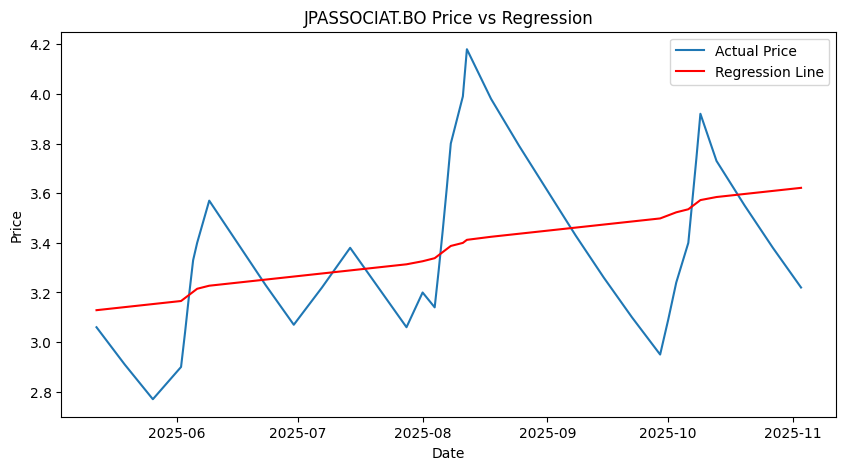

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JINDONL.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for JINDONL.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JAGPRO.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])


No data found for JAGPRO.BO

=== JISLDVREQS.BO ===
                            OLS Regression Results                            
Dep. Variable:          JISLDVREQS.BO   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     6.120
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0147
Time:                        10:38:26   Log-Likelihood:                -260.86
No. Observations:                 128   AIC:                             525.7
Df Residuals:                     126   BIC:                             531.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c

/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


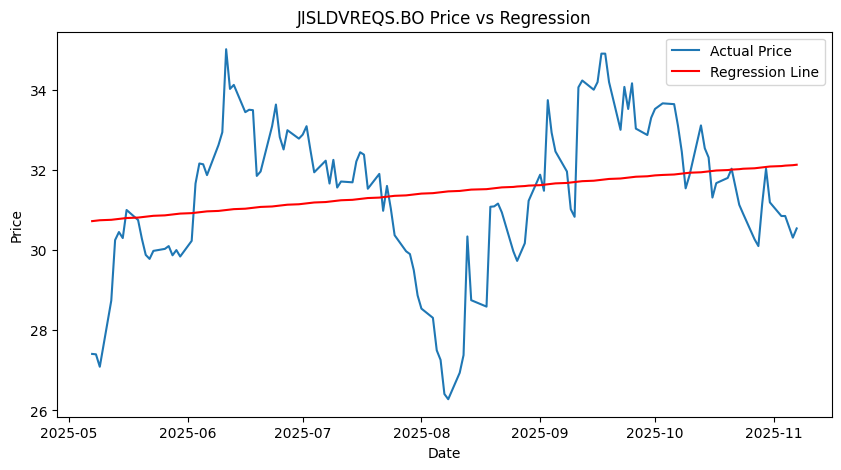

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JPASSOCIAT6.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for JPASSOCIAT6.BO

=== JSTL.BO ===
                            OLS Regression Results                            
Dep. Variable:                JSTL.BO   R-squared:                       0.257
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     43.53
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.04e-09
Time:                        10:38:27   Log-Likelihood:                -427.53
No. Observations:                 128   AIC:                             859.1
Df Residuals:                     126   BIC:                             864.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

[*********************100%***********************]  1 of 1 completed


=== JKAGRI.BO ===
                            OLS Regression Results                            
Dep. Variable:              JKAGRI.BO   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     132.0
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.42e-21
Time:                        10:38:28   Log-Likelihood:                -623.66
No. Observations:                 128   AIC:                             1251.
Df Residuals:                     126   BIC:                             1257.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        374.2239      5.665 


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


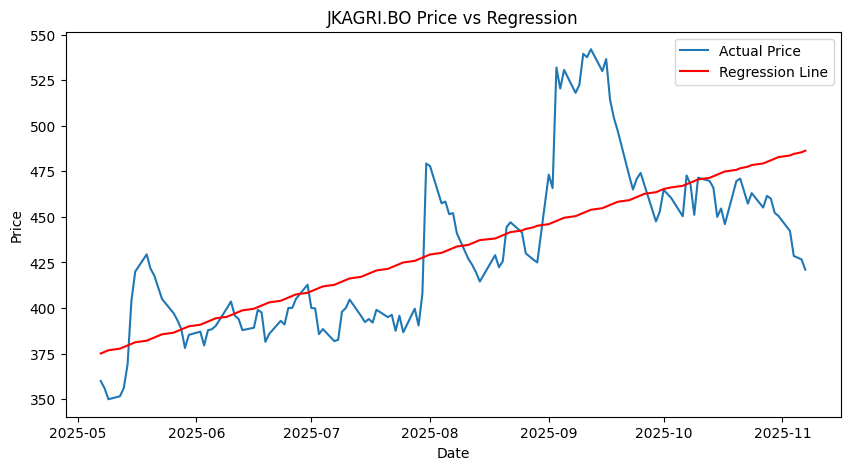

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JAMEHOT.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for JAMEHOT.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JETINFRA.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for JETINFRA.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il

...

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== JAYKAY.BO ===
                            OLS Regression Results                            
Dep. Variable:              JAYKAY.BO   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     91.92
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.11e-16
Time:                        10:38:31   Log-Likelihood:                -590.60
No. Observations:                 128   AIC:                             1185.
Df Residuals:                     126   BIC:                             1191.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        133.8302      4.375 

[*********************100%***********************]  1 of 1 completed


=== JSL.BO ===
                            OLS Regression Results                            
Dep. Variable:                 JSL.BO   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                     392.6
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.57e-40
Time:                        10:38:31   Log-Likelihood:                -604.81
No. Observations:                 128   AIC:                             1214.
Df Residuals:                     126   BIC:                             1219.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        633.2503      4.889    


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


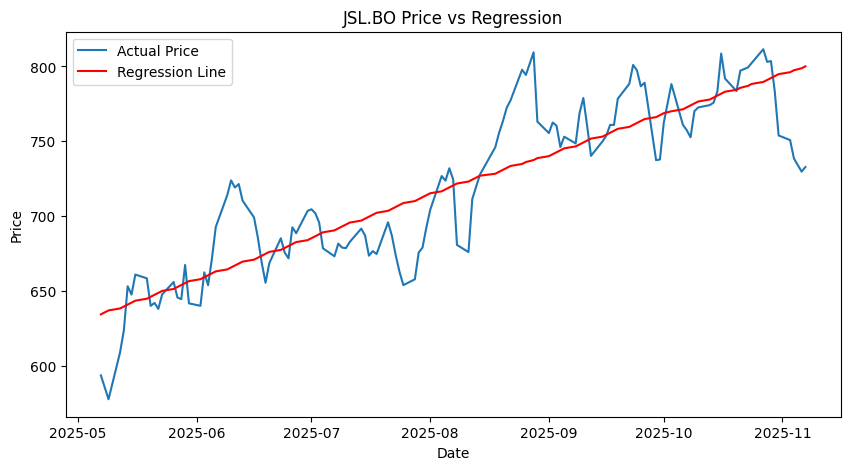

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JAYSYN.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for JAYSYN.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JMCPROJECT.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for JMCPROJECT.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JTLINFRA.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for JTLINFRA.BO


[*********************100%***********************]  1 of 1 completed


=== NARBADA.BO ===
                            OLS Regression Results                            
Dep. Variable:             NARBADA.BO   R-squared:                       0.639
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     223.0
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.18e-29
Time:                        10:38:33   Log-Likelihood:                -388.61
No. Observations:                 128   AIC:                             781.2
Df Residuals:                     126   BIC:                             786.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.1818      0.903


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


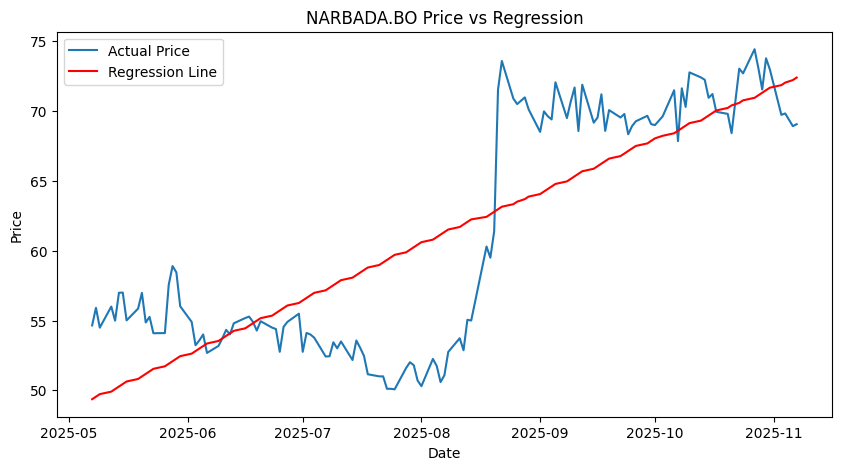

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== JAYUSH.BO ===
                            OLS Regression Results                            
Dep. Variable:              JAYUSH.BO   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     135.0
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.57e-21
Time:                        10:38:34   Log-Likelihood:                -752.83
No. Observations:                 121   AIC:                             1510.
Df Residuals:                     119   BIC:                             1515.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        511.0574     22.479 

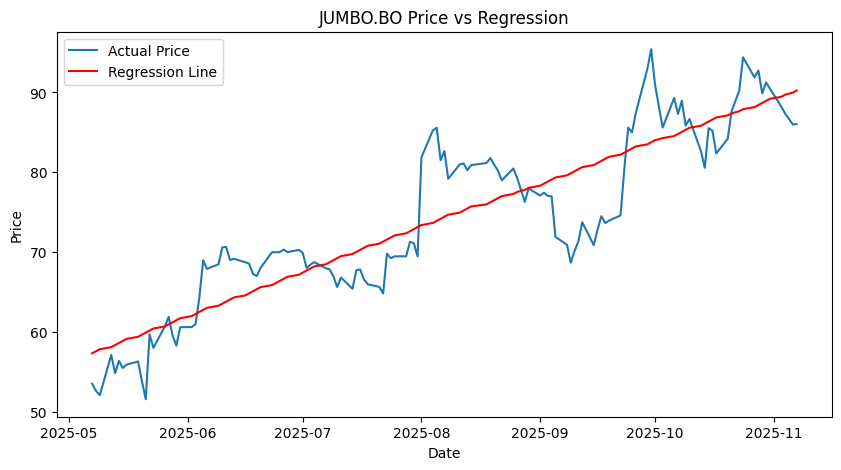

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SAIJEEV.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for SAIJEEV.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JUMBFNL.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for JUMBFNL.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1

...

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== JKTYRE.BO ===
                            OLS Regression Results                            
Dep. Variable:              JKTYRE.BO   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     35.05
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.86e-08
Time:                        10:38:39   Log-Likelihood:                -602.76
No. Observations:                 128   AIC:                             1210.
Df Residuals:                     126   BIC:                             1215.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        338.0220      4.812 

[*********************100%***********************]  1 of 1 completed


=== JAGSNPHARM.BO ===
                            OLS Regression Results                            
Dep. Variable:          JAGSNPHARM.BO   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.5930
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.443
Time:                        10:38:39   Log-Likelihood:                -549.57
No. Observations:                 128   AIC:                             1103.
Df Residuals:                     126   BIC:                             1109.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        230.4100      3.


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


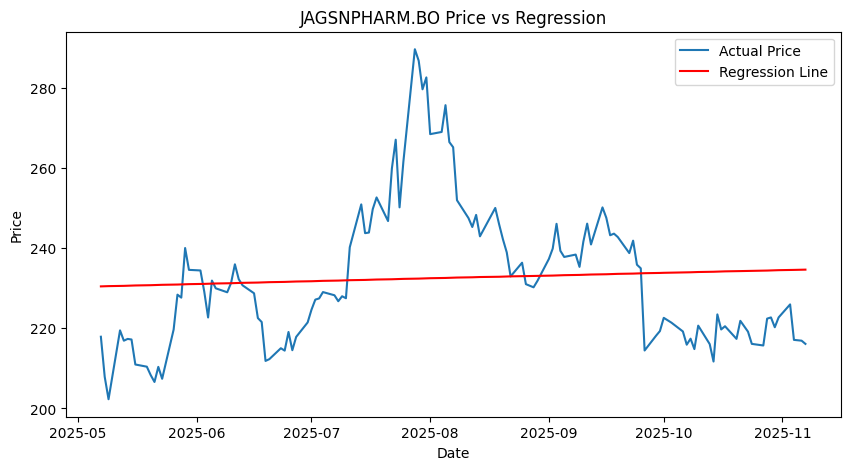

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JMDTELEFILM.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for JMDTELEFILM.BO


[*********************100%***********************]  1 of 1 completed


=== JAYBARMARU.BO ===
                            OLS Regression Results                            
Dep. Variable:          JAYBARMARU.BO   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     302.2
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.84e-35
Time:                        10:38:40   Log-Likelihood:                -412.20
No. Observations:                 128   AIC:                             828.4
Df Residuals:                     126   BIC:                             834.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.8590      1.


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


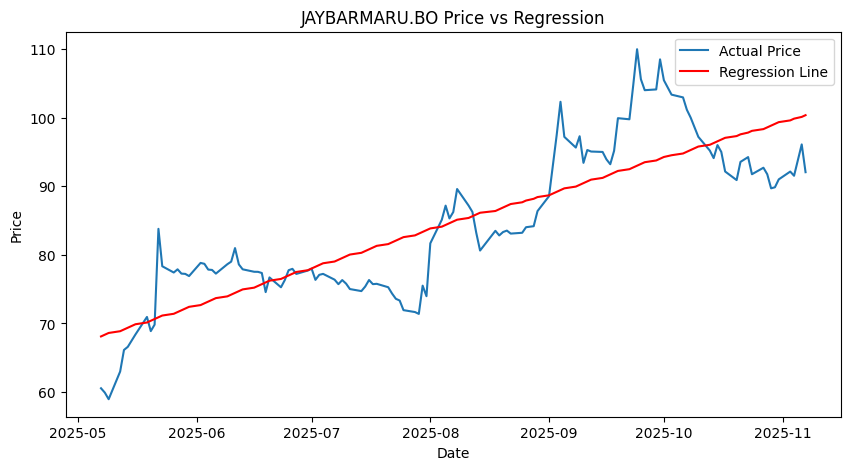

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JAGDAMD.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for JAGDAMD.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JOYREALTY.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for JOYREALTY.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JMPCAST.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


...

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== PCJEWELLER.BO ===
                            OLS Regression Results                            
Dep. Variable:          PCJEWELLER.BO   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.8773
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.351
Time:                        10:38:42   Log-Likelihood:                -242.84
No. Observations:                 128   AIC:                             489.7
Df Residuals:                     126   BIC:                             495.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.5892      0.

[*********************100%***********************]  1 of 1 completed


=== JKPAPER.BO ===
                            OLS Regression Results                            
Dep. Variable:             JKPAPER.BO   R-squared:                       0.506
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     129.3
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           4.76e-21
Time:                        10:38:42   Log-Likelihood:                -547.43
No. Observations:                 128   AIC:                             1099.
Df Residuals:                     126   BIC:                             1105.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        343.2085      3.123


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


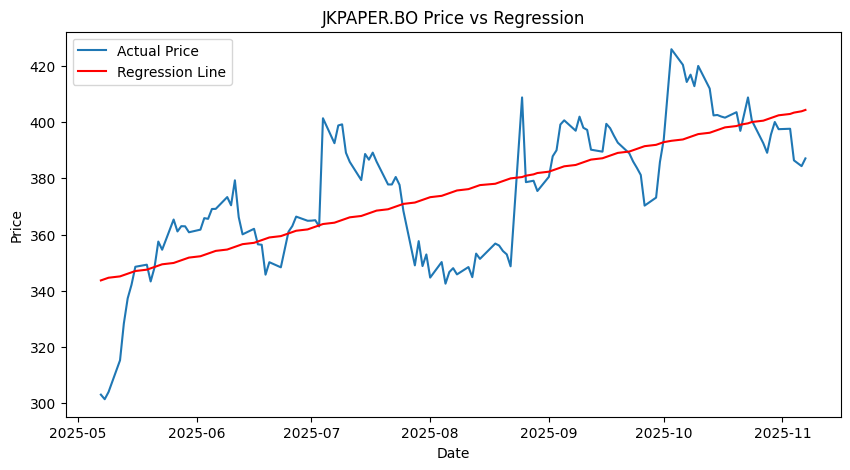

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JMDEPACKR.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for JMDEPACKR.BO

=== JAIMATAG.BO ===
                            OLS Regression Results                            
Dep. Variable:            JAIMATAG.BO   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     11.69
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           0.000847
Time:                        10:38:42   Log-Likelihood:                -45.059
No. Observations:                 128   AIC:                             94.12
Df Residuals:                     126   BIC:                             99.82
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== JINDALPHOT.BO ===
                            OLS Regression Results                            
Dep. Variable:          JINDALPHOT.BO   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.591
Method:                 Least Squares   F-statistic:                     178.6
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.21e-25
Time:                        10:38:42   Log-Likelihood:                -774.81
No. Observations:                 124   AIC:                             1554.
Df Residuals:                     122   BIC:                             1559.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        763.7345     22.

[*********************100%***********************]  1 of 1 completed


=== JKLAKSHMI.BO ===
                            OLS Regression Results                            
Dep. Variable:           JKLAKSHMI.BO   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.877
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.173
Time:                        10:38:43   Log-Likelihood:                -704.02
No. Observations:                 128   AIC:                             1412.
Df Residuals:                     126   BIC:                             1418.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        874.3290     10.6


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


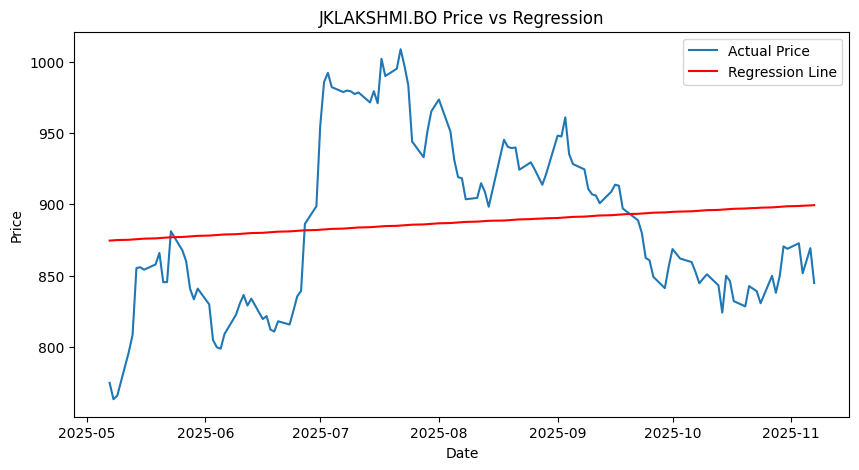

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JTAPARIA.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for JTAPARIA.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JOLLYRID.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for JOLLYRID.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JIYAECO.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


...

No data found for JISLJALEQS6.BO
No data found for SHJAGDM.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed


=== KMSUGAR.BO ===
                            OLS Regression Results                            
Dep. Variable:             KMSUGAR.BO   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     22.74
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           5.03e-06
Time:                        10:38:46   Log-Likelihood:                -163.67
No. Observations:                 128   AIC:                             331.3
Df Residuals:                     126   BIC:                             337.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.0338      0.156


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])


=== SKPMIL.BO ===
                            OLS Regression Results                            
Dep. Variable:              SKPMIL.BO   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     76.76
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.87e-14
Time:                        10:38:46   Log-Likelihood:                -498.48
No. Observations:                 118   AIC:                             1001.
Df Residuals:                     116   BIC:                             1007.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.0696      3.090 

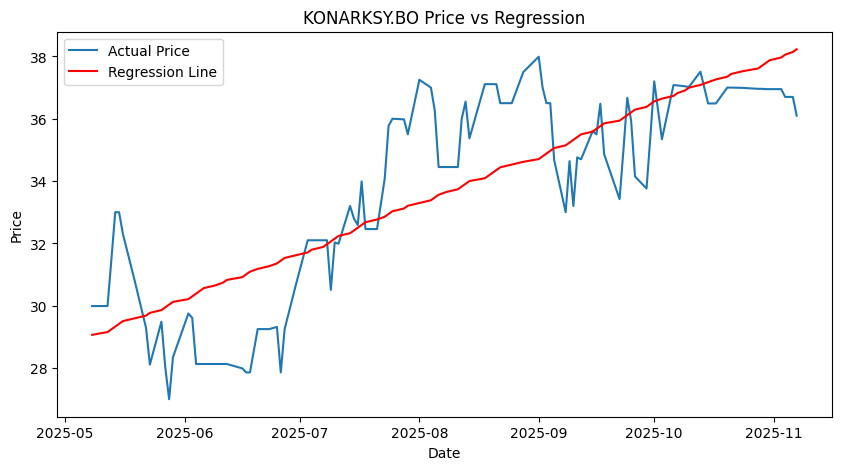

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SONASTEER.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for SONASTEER.BO

=== SHKARTP.BO ===
                            OLS Regression Results                            
Dep. Variable:             SHKARTP.BO   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     44.95
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           6.10e-10
Time:                        10:38:47   Log-Likelihood:                -50.623
No. Observations:                 128   AIC:                             105.2
Df Residuals:                     126   BIC:                             111.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== KUWERIN.BO ===
                            OLS Regression Results                            
Dep. Variable:             KUWERIN.BO   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.439
Method:                 Least Squares   F-statistic:                     96.66
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           4.02e-17
Time:                        10:38:47   Log-Likelihood:                -152.76
No. Observations:                 123   AIC:                             309.5
Df Residuals:                     121   BIC:                             315.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.1036      0.153

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il

...

No data found for KILPEST.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['KILBURN.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for KILBURN.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['KHODAY.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for KHODAY.BO

=== KHANDSE.BO ===
                            OLS Regression Results                            
Dep. Variable:             KHANDSE.BO   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                  0.006408
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.936
Time:                        10:38:53   Log-Likelihood:                -166.65
No. Observations:                 114   AIC:                             337.3
Df Residuals:                     112   BIC:                             342.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons

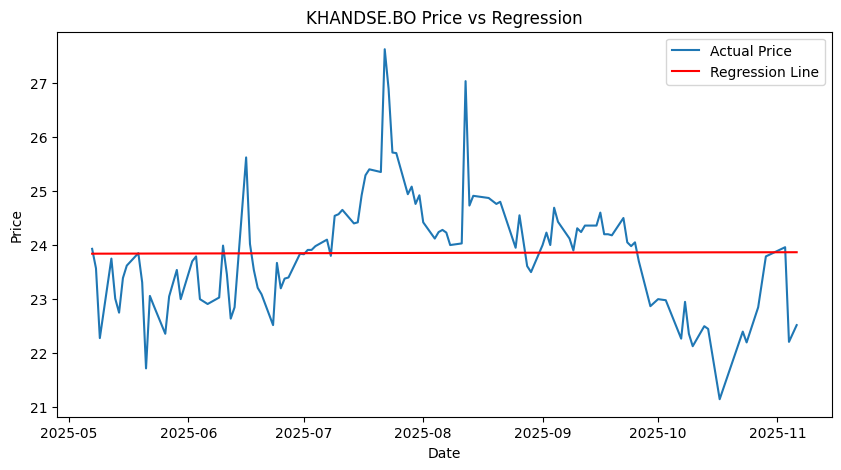

[*********************100%***********************]  1 of 1 completed


=== KHAITANLTD.BO ===
                            OLS Regression Results                            
Dep. Variable:          KHAITANLTD.BO   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     4.078
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0458
Time:                        10:38:53   Log-Likelihood:                -454.66
No. Observations:                 116   AIC:                             913.3
Df Residuals:                     114   BIC:                             918.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        118.2034      2.


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


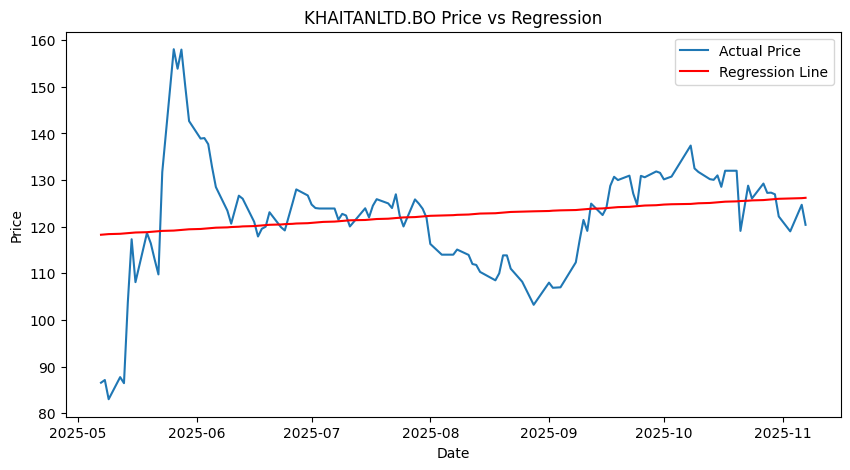

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== KENNAMET.BO ===
                            OLS Regression Results                            
Dep. Variable:            KENNAMET.BO   R-squared:                       0.445
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     101.0
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           8.25e-18
Time:                        10:38:54   Log-Likelihood:                -780.33
No. Observations:                 128   AIC:                             1565.
Df Residuals:                     126   BIC:                             1570.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2395.8059     19.26

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== KEMP.BO ===
                            OLS Regression Results                            
Dep. Variable:                KEMP.BO   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     10.65
Date:                Sun, 09 Nov 2025   Prob (F-statistic):            0.00175
Time:                        10:38:54   Log-Likelihood:                -422.52
No. Observations:                  68   AIC:                             849.0
Df Residuals:                      66   BIC:                             853.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1447.6779     30.085   

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


...

No data found for KILBURNC.BO

=== KAIRA.BO ===
                            OLS Regression Results                            
Dep. Variable:               KAIRA.BO   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     97.79
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           3.41e-17
Time:                        10:38:59   Log-Likelihood:                -644.80
No. Observations:                 121   AIC:                             1294.
Df Residuals:                     119   BIC:                             1299.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['KUSHAL.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed

No data found for KUSHAL.BO

=== KANELIND.BO ===
                            OLS Regression Results                            
Dep. Variable:            KANELIND.BO   R-squared:                        -inf
Model:                            OLS   Adj. R-squared:                   -inf
Method:                 Least Squares   F-statistic:                    -127.0
Date:                Sun, 09 Nov 2025   Prob (F-statistic):               1.00
Time:                        10:39:00   Log-Likelihood:                 4019.5
No. Observations:                 129   AIC:                            -8035.
Df Residuals:                     127   BIC:                            -8029.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/stats/stattools.py:125: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew = stats.skew(resids, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/stats/stattools.py:126: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis = 3 + stats.kurtosis(resids, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.11/lib/py


=== KANDAGIRI.BO ===
                            OLS Regression Results                            
Dep. Variable:           KANDAGIRI.BO   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     159.6
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.37e-12
Time:                        10:39:00   Log-Likelihood:                -31.438
No. Observations:                  27   AIC:                             66.88
Df Residuals:                      25   BIC:                             69.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.7414      0.3

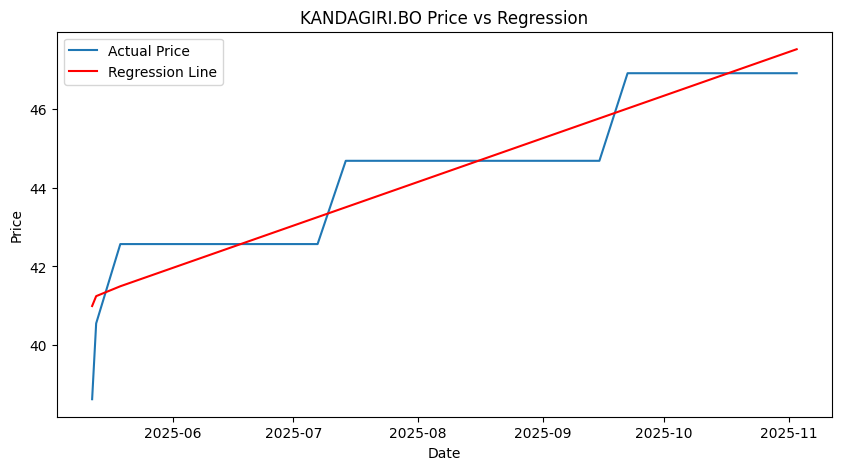

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])



=== SPICEJET.BO ===
                            OLS Regression Results                            
Dep. Variable:            SPICEJET.BO   R-squared:                       0.695
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     286.5
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           3.03e-34
Time:                        10:39:00   Log-Likelihood:                -305.49
No. Observations:                 128   AIC:                             615.0
Df Residuals:                     126   BIC:                             620.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         44.4850      0.47

/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a valu

Recommendation: No buy signal for SPICEJET.BO

=== RPOWER.BO ===
                            OLS Regression Results                            
Dep. Variable:              RPOWER.BO   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     38.44
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           7.42e-09
Time:                        10:39:00   Log-Likelihood:                -450.27
No. Observations:                 128   AIC:                             904.5
Df Residuals:                     126   BIC:                             910.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['WARNER.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for WARNER.BO

=== WALCHPF.BO ===
                            OLS Regression Results                            
Dep. Variable:             WALCHPF.BO   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     3.680
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0574
Time:                        10:39:01   Log-Likelihood:                -461.62
No. Observations:                 125   AIC:                             927.2
Df Residuals:                     123   BIC:                             932.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons

[*********************100%***********************]  1 of 1 completed


=== TCI.BO ===
                            OLS Regression Results                            
Dep. Variable:                 TCI.BO   R-squared:                       0.328
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     61.40
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.68e-12
Time:                        10:39:01   Log-Likelihood:                -621.18
No. Observations:                 128   AIC:                             1246.
Df Residuals:                     126   BIC:                             1252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1126.4474      5.556    


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


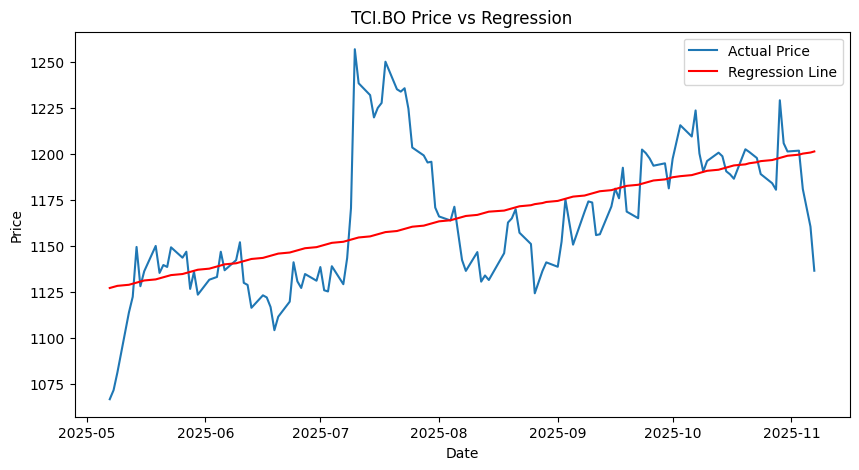

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== STANPACK.BO ===
                            OLS Regression Results                            
Dep. Variable:            STANPACK.BO   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                     19.09
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.68e-05
Time:                        10:39:02   Log-Likelihood:                -193.83
No. Observations:                 121   AIC:                             391.7
Df Residuals:                     119   BIC:                             397.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.7368      0.22

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['RELCAPITAL.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for RELCAPITAL.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== INDRAMEDCO.BO ===
                            OLS Regression Results                            
Dep. Variable:          INDRAMEDCO.BO   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                     213.4
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           6.91e-29
Time:                        10:39:04   Log-Likelihood:                -632.79
No. Observations:                 128   AIC:                             1270.
Df Residuals:                     126   BIC:                             1275.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        392.5756      6.

[*********************100%***********************]  1 of 1 completed


=== ZYDUSWELL.BO ===
                            OLS Regression Results                            
Dep. Variable:           ZYDUSWELL.BO   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     325.6
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           9.84e-37
Time:                        10:39:04   Log-Likelihood:                -591.05
No. Observations:                 128   AIC:                             1186.
Df Residuals:                     126   BIC:                             1192.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        354.1118      4.3


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


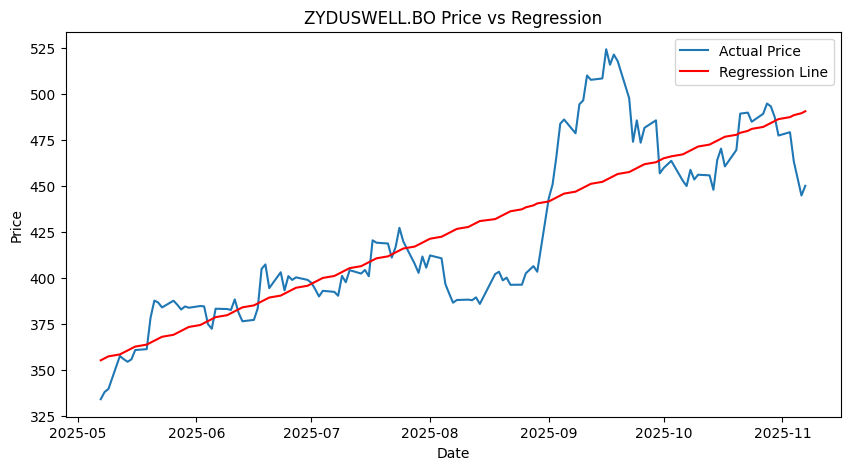

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== ZENOTECH.BO ===
                            OLS Regression Results                            
Dep. Variable:            ZENOTECH.BO   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     269.2
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           4.50e-33
Time:                        10:39:04   Log-Likelihood:                -303.58
No. Observations:                 128   AIC:                             611.2
Df Residuals:                     126   BIC:                             616.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         64.0284      0.46

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['YASHPPR.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for YASHPPR.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['WELSPSY.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


...

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TRICOM.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for TRICOM.BO


[*********************100%***********************]  1 of 1 completed


=== TATACHEM.BO ===
                            OLS Regression Results                            
Dep. Variable:            TATACHEM.BO   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     17.17
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           6.22e-05
Time:                        10:39:08   Log-Likelihood:                -644.87
No. Observations:                 128   AIC:                             1294.
Df Residuals:                     126   BIC:                             1299.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        897.5582      6.68


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


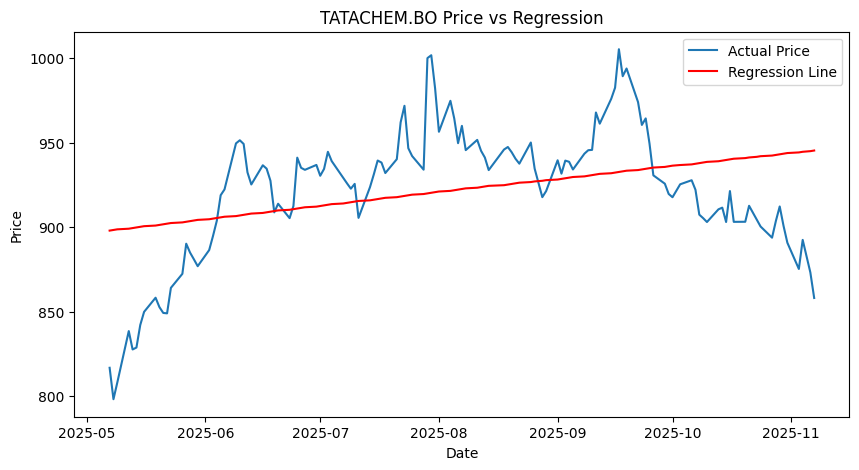

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SUDIN.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])


No data found for SUDIN.BO

=== STURDY.BO ===
                            OLS Regression Results                            
Dep. Variable:              STURDY.BO   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     3.851
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0614
Time:                        10:39:09   Log-Likelihood:                 64.774
No. Observations:                  26   AIC:                            -125.5
Df Residuals:                      24   BIC:                            -123.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


Recommendation: No buy signal for STURDY.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SPICEISL.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for SPICEISL.BO

=== SOFTSOL.BO ===
                            OLS Regression Results                            
Dep. Variable:             SOFTSOL.BO   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     23.07
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           4.45e-06
Time:                        10:39:09   Log-Likelihood:                -490.82
No. Observations:                 125   AIC:                             985.6
Df Residuals:                     123   BIC:                             991.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

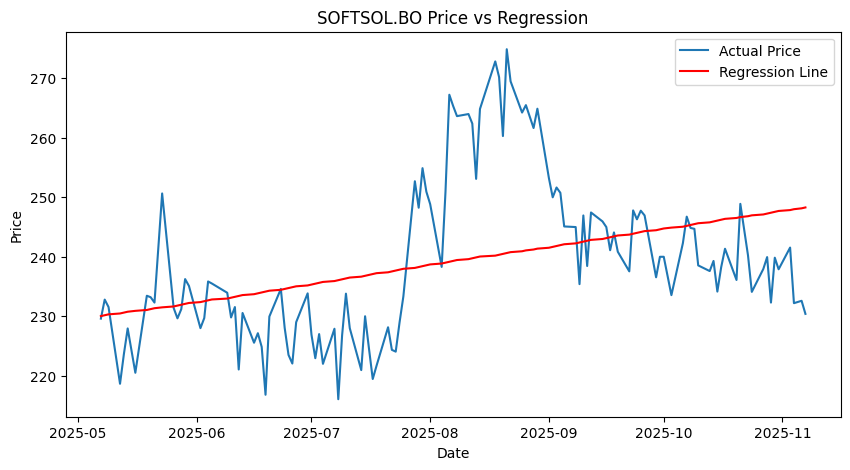

[*********************100%***********************]  1 of 1 completed


=== SKYIND.BO ===
                            OLS Regression Results                            
Dep. Variable:              SKYIND.BO   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.684
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.197
Time:                        10:39:10   Log-Likelihood:                -437.03
No. Observations:                 128   AIC:                             878.1
Df Residuals:                     126   BIC:                             883.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         93.2770      1.318 


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


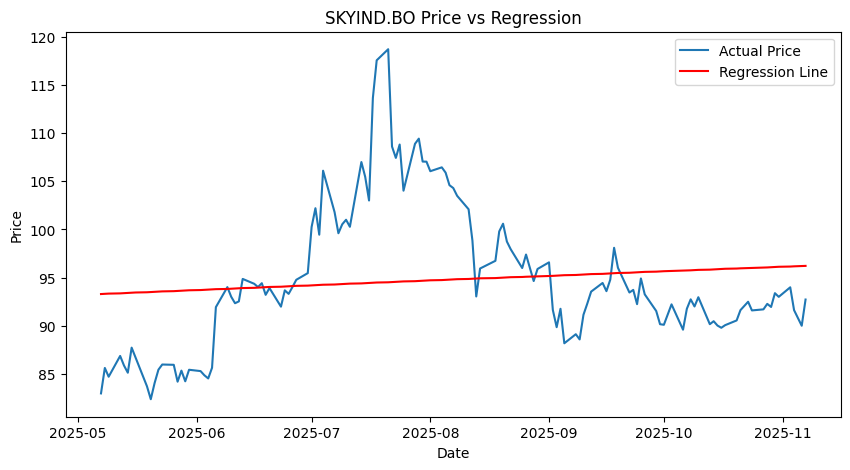

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])



=== SKRABUL.BO ===
                            OLS Regression Results                            
Dep. Variable:             SKRABUL.BO   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     59.72
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.25e-11
Time:                        10:39:10   Log-Likelihood:                -245.74
No. Observations:                  95   AIC:                             495.5
Df Residuals:                      93   BIC:                             500.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.2020      0.672

/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SIMPLEX.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SHUKUN.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for SIMPLEX.BO
No data found for SHUKUN.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed


=== SHREECEM.BO ===
                            OLS Regression Results                            
Dep. Variable:            SHREECEM.BO   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     36.19
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.80e-08
Time:                        10:39:11   Log-Likelihood:                -1043.4
No. Observations:                 128   AIC:                             2091.
Df Residuals:                     126   BIC:                             2097.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.073e+04    150.43


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['MUTHTFN.BO']: YFPricesMissingE

No data found for MUTHTFN.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['MPHASIS6.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for MPHASIS6.BO

=== MOSCHIP.BO ===
                            OLS Regression Results                            
Dep. Variable:             MOSCHIP.BO   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                     186.3
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.33e-26
Time:                        10:39:13   Log-Likelihood:                -597.74
No. Observations:                 128   AIC:                             1199.
Df Residuals:                     126   BIC:                             1205.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

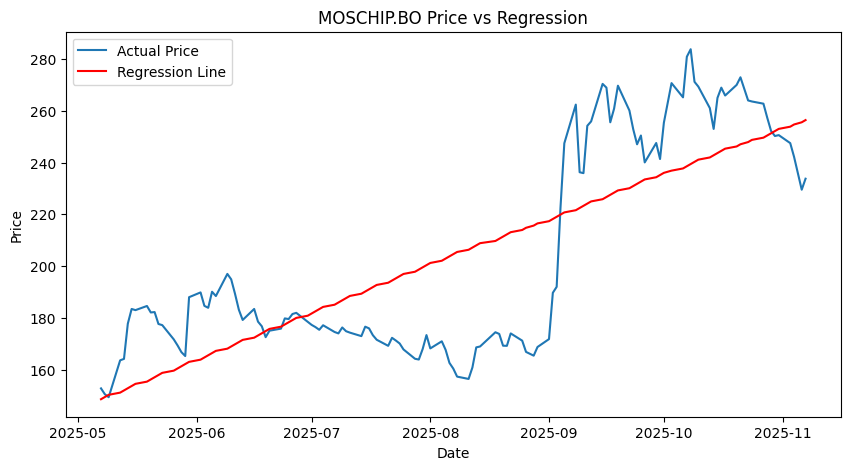

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== MCLEODRUSS.BO ===
                            OLS Regression Results                            
Dep. Variable:          MCLEODRUSS.BO   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     195.3
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.22e-27
Time:                        10:39:13   Log-Likelihood:                -412.45
No. Observations:                 128   AIC:                             828.9
Df Residuals:                     126   BIC:                             834.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.9504      1.

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== RAJTV.BO ===
                            OLS Regression Results                            
Dep. Variable:               RAJTV.BO   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     386.1
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           7.34e-39
Time:                        10:39:13   Log-Likelihood:                -195.47
No. Observations:                 119   AIC:                             394.9
Df Residuals:                     117   BIC:                             400.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.9268      0.233  

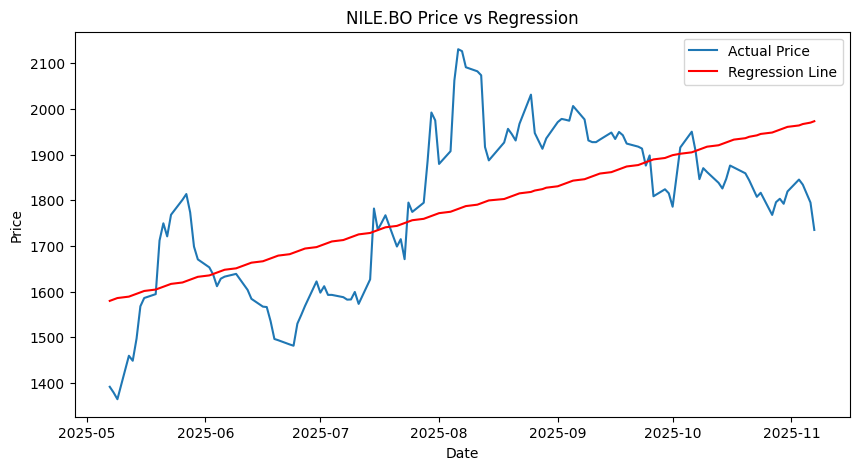

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== NETTLINX.BO ===
                            OLS Regression Results                            
Dep. Variable:            NETTLINX.BO   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     156.9
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           7.05e-24
Time:                        10:39:14   Log-Likelihood:                -282.81
No. Observations:                 128   AIC:                             569.6
Df Residuals:                     126   BIC:                             575.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.8652      0.39

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['NATPEROX.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer key

No data found for NATPEROX.BO

=== ZNEWSAGA.BO ===
                            OLS Regression Results                            
Dep. Variable:            ZNEWSAGA.BO   R-squared:                        -inf
Model:                            OLS   Adj. R-squared:                   -inf
Method:                 Least Squares   F-statistic:                    -127.0
Date:                Sun, 09 Nov 2025   Prob (F-statistic):               1.00
Time:                        10:39:14   Log-Likelihood:                 4082.6
No. Observations:                 129   AIC:                            -8161.
Df Residuals:                     127   BIC:                            -8155.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== SUNTV.BO ===
                            OLS Regression Results                            
Dep. Variable:               SUNTV.BO   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.580
Method:                 Least Squares   F-statistic:                     176.6
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           9.89e-26
Time:                        10:39:15   Log-Likelihood:                -548.39
No. Observations:                 128   AIC:                             1101.
Df Residuals:                     126   BIC:                             1106.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        616.2847      3.146  

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== SMARTLINK.BO ===
                            OLS Regression Results                            
Dep. Variable:           SMARTLINK.BO   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     145.1
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.18e-22
Time:                        10:39:15   Log-Likelihood:                -407.88
No. Observations:                 127   AIC:                             819.8
Df Residuals:                     125   BIC:                             825.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        161.9483      1.0

/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


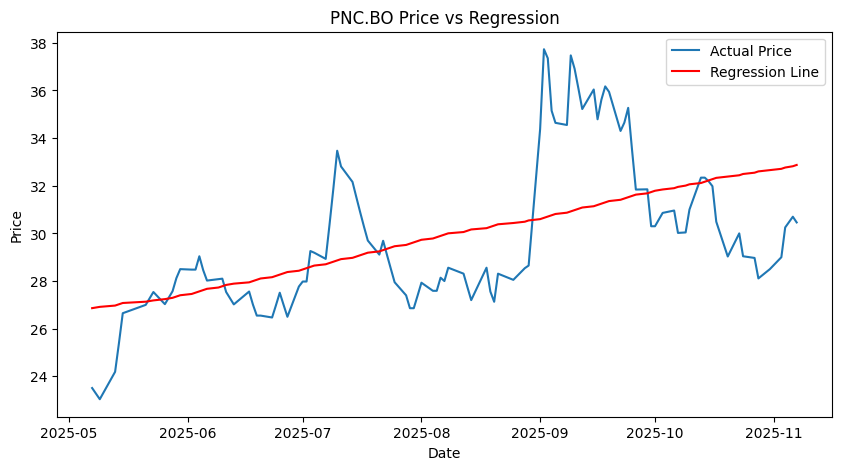

[*********************100%***********************]  1 of 1 completed


=== NTPC.BO ===
                            OLS Regression Results                            
Dep. Variable:                NTPC.BO   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     4.978
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0274
Time:                        10:39:15   Log-Likelihood:                -392.32
No. Observations:                 128   AIC:                             788.6
Df Residuals:                     126   BIC:                             794.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        330.2466      0.930   


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


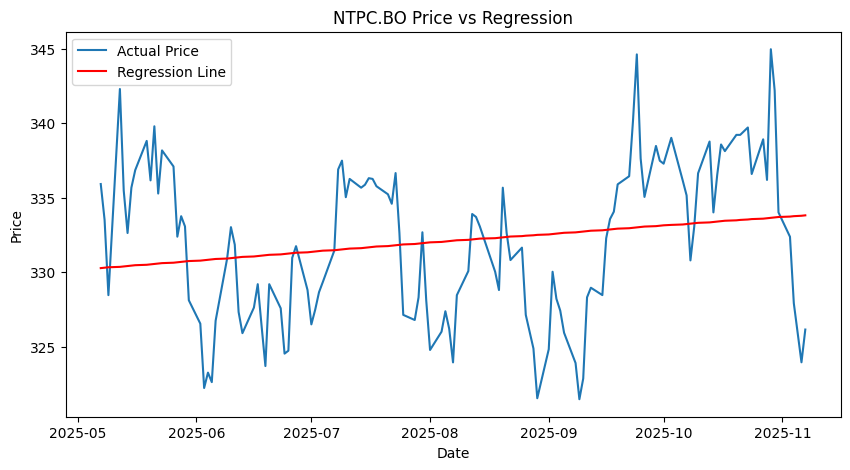

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== NPRFIN.BO ===
                            OLS Regression Results                            
Dep. Variable:              NPRFIN.BO   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     252.3
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.74e-31
Time:                        10:39:16   Log-Likelihood:                -245.38
No. Observations:                 124   AIC:                             494.8
Df Residuals:                     122   BIC:                             500.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.6759      0.319 

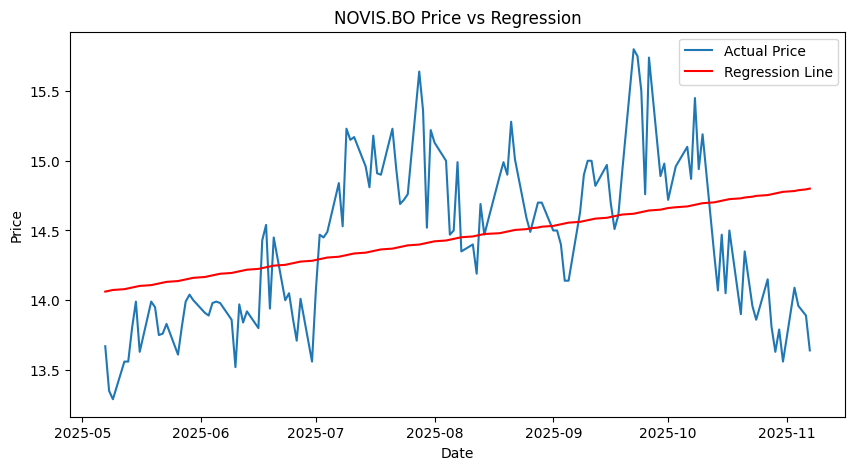

[*********************100%***********************]  1 of 1 completed


=== NNTL.BO ===
                            OLS Regression Results                            
Dep. Variable:                NNTL.BO   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     223.9
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.41e-13
Time:                        10:39:16   Log-Likelihood:                -47.169
No. Observations:                  25   AIC:                             98.34
Df Residuals:                      23   BIC:                             100.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.1935      0.686   


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


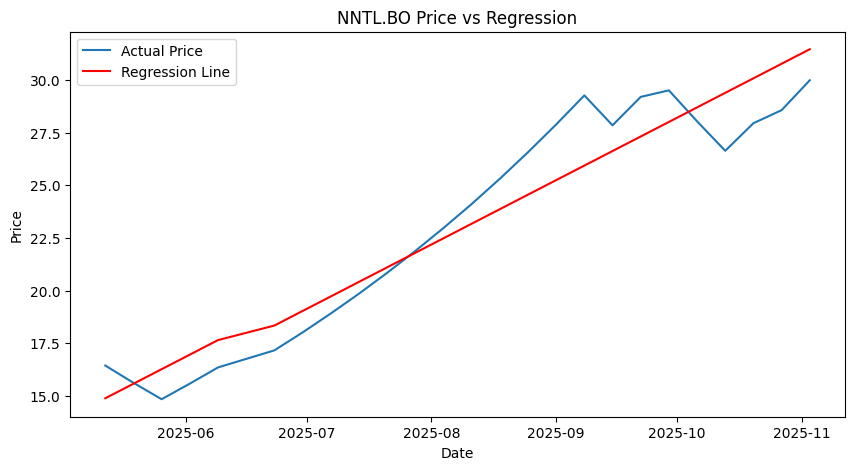

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed



=== NITINSPIN.BO ===
                            OLS Regression Results                            
Dep. Variable:           NITINSPIN.BO   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     409.3
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.15e-41
Time:                        10:39:16   Log-Likelihood:                -515.76
No. Observations:                 128   AIC:                             1036.
Df Residuals:                     126   BIC:                             1041.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        401.8035      2.4

/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])



=== NITCO.BO ===
                            OLS Regression Results                            
Dep. Variable:               NITCO.BO   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     136.5
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           8.04e-22
Time:                        10:39:17   Log-Likelihood:                -469.42
No. Observations:                 128   AIC:                             942.8
Df Residuals:                     126   BIC:                             948.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        143.5264      1.698  

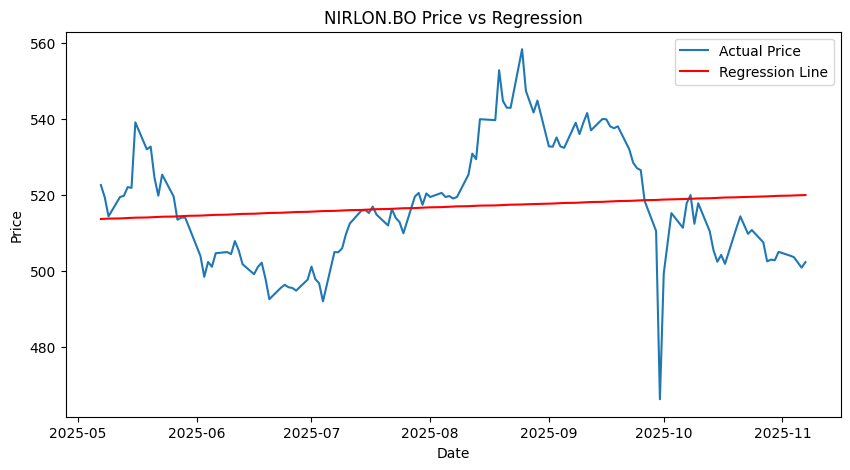

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== NIRAJ.BO ===
                            OLS Regression Results                            
Dep. Variable:               NIRAJ.BO   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     581.0
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           5.04e-49
Time:                        10:39:17   Log-Likelihood:                -342.32
No. Observations:                 128   AIC:                             688.6
Df Residuals:                     126   BIC:                             694.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         61.8714      0.629  

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['NILA.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['NIJJER.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for NILA.BO
No data found for NIJJER.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['NIITTECH.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for NIITTECH.BO


[*********************100%***********************]  1 of 1 completed


=== NIHARINF.BO ===
                            OLS Regression Results                            
Dep. Variable:            NIHARINF.BO   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     59.02
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           9.46e-12
Time:                        10:39:19   Log-Likelihood:                -68.354
No. Observations:                 105   AIC:                             140.7
Df Residuals:                     103   BIC:                             146.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1378      0.09


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


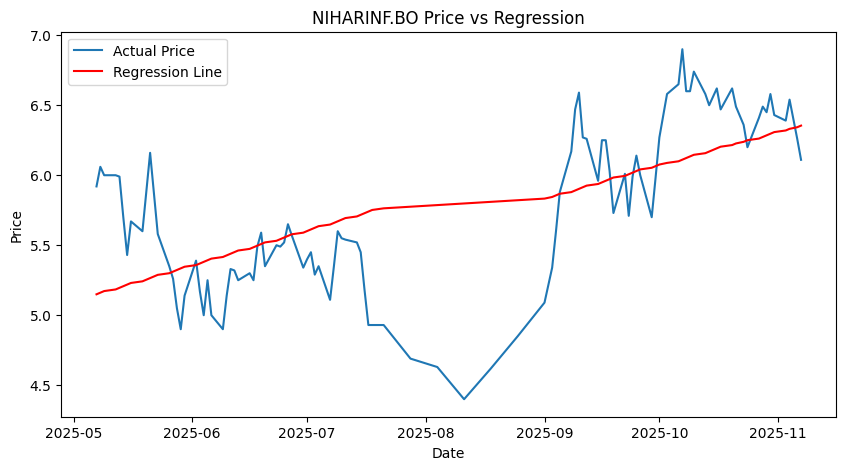

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== NIDHGRN.BO ===
                            OLS Regression Results                            
Dep. Variable:             NIDHGRN.BO   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     1588.
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           4.82e-71
Time:                        10:39:19   Log-Likelihood:                -567.71
No. Observations:                 122   AIC:                             1139.
Df Residuals:                     120   BIC:                             1145.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        107.4912      4.665

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['NEYVELILIG.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')



=== NFL.BO ===
                            OLS Regression Results                            
Dep. Variable:                 NFL.BO   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     3.624
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0592
Time:                        10:39:19   Log-Likelihood:                -363.34
No. Observations:                 128   AIC:                             730.7
Df Residuals:                     126   BIC:                             736.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         96.9875      0.741    

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['NETWORTH.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for NETWORTH.BO


[*********************100%***********************]  1 of 1 completed


=== NELCAST.BO ===
                            OLS Regression Results                            
Dep. Variable:             NELCAST.BO   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.1233
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.726
Time:                        10:39:20   Log-Likelihood:                -560.35
No. Observations:                 128   AIC:                             1125.
Df Residuals:                     126   BIC:                             1130.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        137.1266      3.454


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


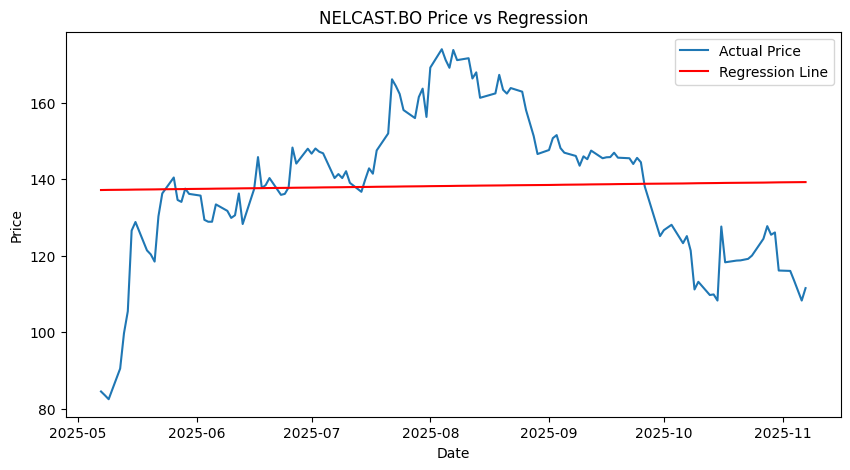

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== NEELKAN.BO ===
                            OLS Regression Results                            
Dep. Variable:             NEELKAN.BO   R-squared:                       0.142
Model:                            OLS   Adj. R-squared:                  0.133
Method:                 Least Squares   F-statistic:                     17.31
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           6.52e-05
Time:                        10:39:20   Log-Likelihood:                -186.46
No. Observations:                 107   AIC:                             376.9
Df Residuals:                     105   BIC:                             382.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.2697      0.272

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed



=== SAIL.BO ===
                            OLS Regression Results                            
Dep. Variable:                SAIL.BO   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.279
Method:                 Least Squares   F-statistic:                     50.04
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           9.23e-11
Time:                        10:39:20   Log-Likelihood:                -406.00
No. Observations:                 128   AIC:                             816.0
Df Residuals:                     126   BIC:                             821.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        120.8720      1.034   

/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TINPLATE.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['STOREONE.BO']: YFPricesMissingError('possibly delisted; no price data fou

No data found for TINPLATE.BO
No data found for STOREONE.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== SCI.BO ===
                            OLS Regression Results                            
Dep. Variable:                 SCI.BO   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     185.6
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.53e-26
Time:                        10:39:21   Log-Likelihood:                -515.13
No. Observations:                 128   AIC:                             1034.
Df Residuals:                     126   BIC:                             1040.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        184.7193      2.426    

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['RAJOIL.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for RAJOIL.BO

=== OXFORDIN.BO ===
                            OLS Regression Results                            
Dep. Variable:            OXFORDIN.BO   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     632.7
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.19e-22
Time:                        10:39:22   Log-Likelihood:                 20.645
No. Observations:                  34   AIC:                            -37.29
Df Residuals:                      32   BIC:                            -34.24
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

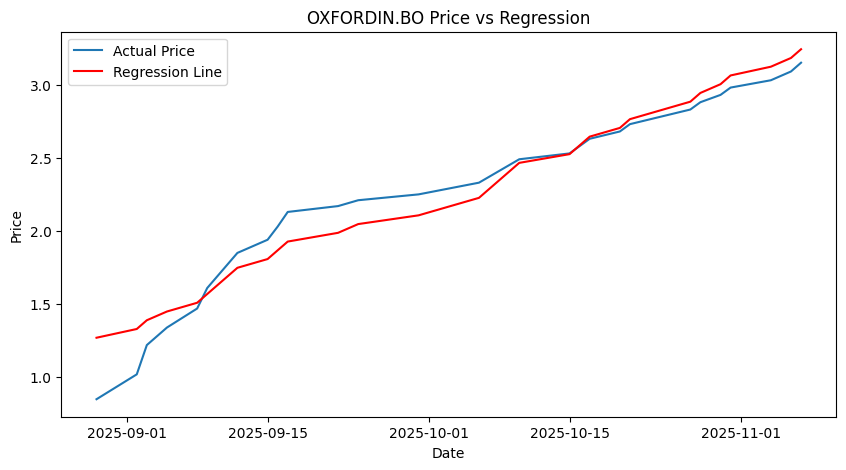

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== OVOBELE.BO ===
                            OLS Regression Results                            
Dep. Variable:             OVOBELE.BO   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     414.7
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.13e-41
Time:                        10:39:22   Log-Likelihood:                -498.98
No. Observations:                 128   AIC:                             1002.
Df Residuals:                     126   BIC:                             1008.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         86.6870      2.139

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['OSCAR.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for OSCAR.BO

=== ORIENTLTD.BO ===
                            OLS Regression Results                            
Dep. Variable:           ORIENTLTD.BO   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                   0.08466
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.772
Time:                        10:39:23   Log-Likelihood:                -347.85
No. Observations:                 126   AIC:                             699.7
Df Residuals:                     124   BIC:                             705.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

[*********************100%***********************]  1 of 1 completed


=== ORIENTBELL.BO ===
                            OLS Regression Results                            
Dep. Variable:          ORIENTBELL.BO   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     19.80
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.87e-05
Time:                        10:39:23   Log-Likelihood:                -555.77
No. Observations:                 128   AIC:                             1116.
Df Residuals:                     126   BIC:                             1121.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        279.6339      3.


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


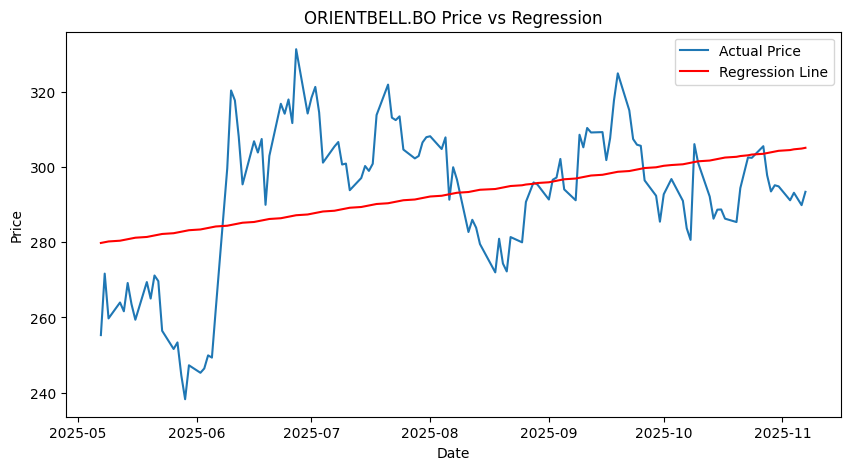

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ORCHIDCHEM.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')



=== ORGCOAT.BO ===
                            OLS Regression Results                            
Dep. Variable:             ORGCOAT.BO   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     112.9
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           5.95e-19
Time:                        10:39:24   Log-Likelihood:                -301.16
No. Observations:                 121   AIC:                             606.3
Df Residuals:                     119   BIC:                             611.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.3436      0.538

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['OMNITECH.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')
[*********************100%***********************]  1 of 1 completed

No data found for OMNITECH.BO



/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])


=== OMKARCHEM.BO ===
                            OLS Regression Results                            
Dep. Variable:           OMKARCHEM.BO   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     37.78
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           9.63e-09
Time:                        10:39:24   Log-Likelihood:                -129.10
No. Observations:                 128   AIC:                             262.2
Df Residuals:                     126   BIC:                             267.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1489      0.1

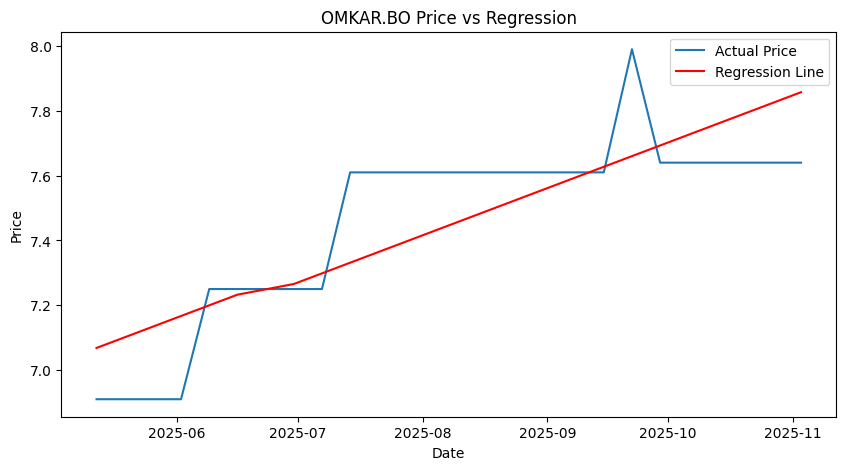

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== OMAXE.BO ===
                            OLS Regression Results                            
Dep. Variable:               OMAXE.BO   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     15.98
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           0.000108
Time:                        10:39:24   Log-Likelihood:                -462.47
No. Observations:                 128   AIC:                             928.9
Df Residuals:                     126   BIC:                             934.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         95.9498      1.608  

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== OIL.BO ===
                            OLS Regression Results                            
Dep. Variable:                 OIL.BO   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.133
Method:                 Least Squares   F-statistic:                     20.49
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.37e-05
Time:                        10:39:25   Log-Likelihood:                -556.56
No. Observations:                 128   AIC:                             1117.
Df Residuals:                     126   BIC:                             1123.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        437.2761      3.354    

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['OCL.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for OCL.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['MRUTIOR--.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for MRUTIOR--.BO

=== LAHOTIOV.BO ===
                            OLS Regression Results                            
Dep. Variable:            LAHOTIOV.BO   R-squared:                       0.877
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     897.6
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           3.66e-59
Time:                        10:39:26   Log-Likelihood:                -307.47
No. Observations:                 128   AIC:                             618.9
Df Residuals:                     126   BIC:                             624.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


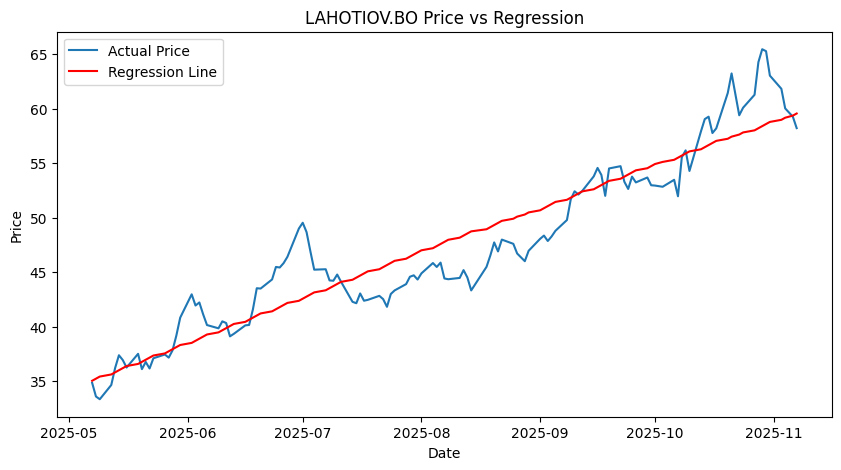

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== IOC.BO ===
                            OLS Regression Results                            
Dep. Variable:                 IOC.BO   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     119.7
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           5.44e-20
Time:                        10:39:26   Log-Likelihood:                -393.95
No. Observations:                 128   AIC:                             791.9
Df Residuals:                     126   BIC:                             797.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        136.2359      0.941    

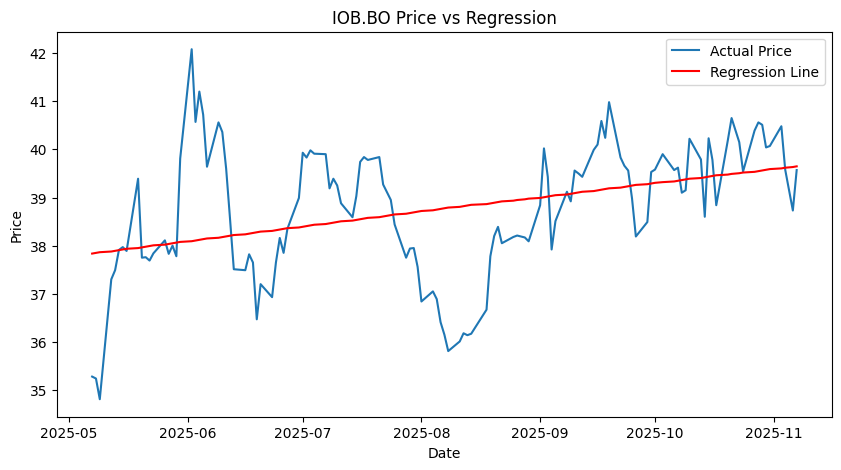

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== GKB.BO ===
                            OLS Regression Results                            
Dep. Variable:                 GKB.BO   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.202
Method:                 Least Squares   F-statistic:                     32.57
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           8.01e-08
Time:                        10:39:27   Log-Likelihood:                -356.65
No. Observations:                 126   AIC:                             717.3
Df Residuals:                     124   BIC:                             723.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         76.6383      0.741    

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== CENTRALBK.BO ===
                            OLS Regression Results                            
Dep. Variable:           CENTRALBK.BO   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.569
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.213
Time:                        10:39:27   Log-Likelihood:                -233.66
No. Observations:                 128   AIC:                             471.3
Df Residuals:                     126   BIC:                             477.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.9661      0.2

/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a valu


=== AKSHOPTFBR.BO ===
                            OLS Regression Results                            
Dep. Variable:          AKSHOPTFBR.BO   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     618.7
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.90e-50
Time:                        10:39:27   Log-Likelihood:                -31.779
No. Observations:                 128   AIC:                             67.56
Df Residuals:                     126   BIC:                             73.26
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.5849      0.

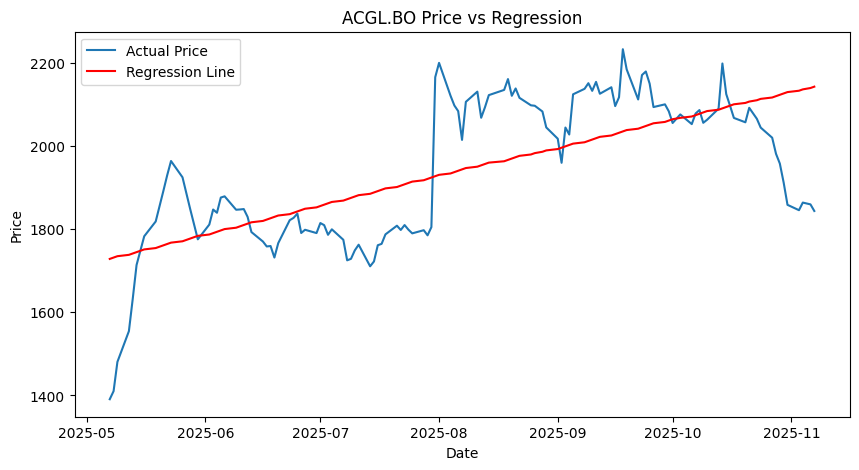

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['OCEAGRO.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TRANSPEKF.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')


No data found for OCEAGRO.BO
No data found for TRANSPEKF.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['OXIDE.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for OXIDE.BO


[*********************100%***********************]  1 of 1 completed


=== GULFOILLUB.BO ===
                            OLS Regression Results                            
Dep. Variable:          GULFOILLUB.BO   R-squared:                       0.300
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     53.94
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.27e-11
Time:                        10:39:29   Log-Likelihood:                -624.24
No. Observations:                 128   AIC:                             1252.
Df Residuals:                     126   BIC:                             1258.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1168.3487      5.


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


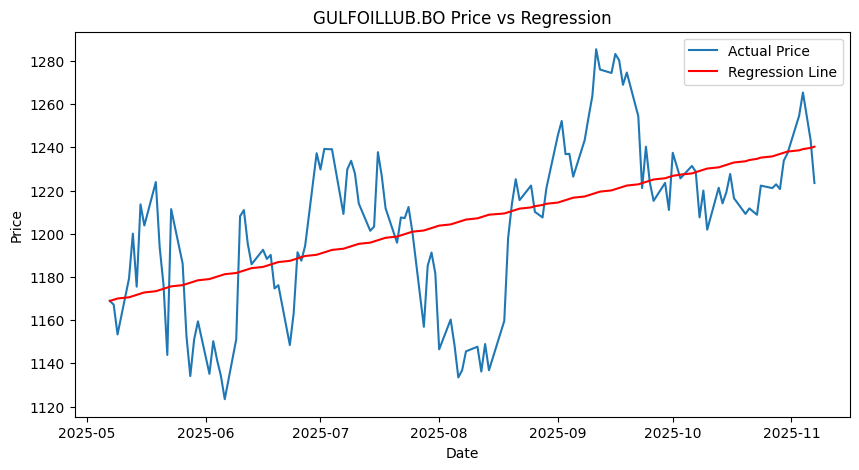

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['MCX6.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for MCX6.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== ORIENTPPR.BO ===
                            OLS Regression Results                            
Dep. Variable:           ORIENTPPR.BO   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     32.11
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           9.43e-08
Time:                        10:39:30   Log-Likelihood:                -226.02
No. Observations:                 128   AIC:                             456.0
Df Residuals:                     126   BIC:                             461.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.1600      0.2

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ORNTSYN.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


...

No data found for MNSGOIL.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['CONCOR4.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for CONCOR4.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SAHARA.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for SAHARA.BO

=== OPTIEMUS.BO ===
                            OLS Regression Results                            
Dep. Variable:            OPTIEMUS.BO   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     18.14
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           3.98e-05
Time:                        10:39:34   Log-Likelihood:                -633.79
No. Observations:                 128   AIC:                             1272.
Df Residuals:                     126   BIC:                             1277.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

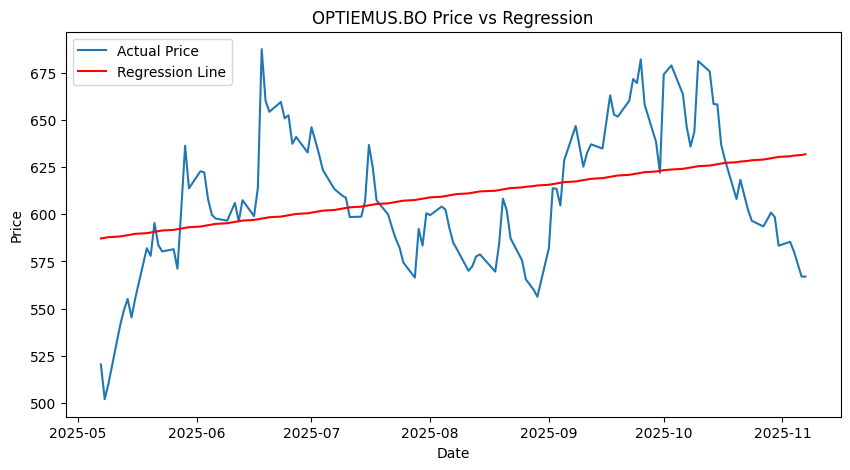

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SVOGL.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for SVOGL.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TUBEINVEST6.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for TUBEINVEST6.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['DOLPHINOFF.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as p

No data found for DOLPHINOFF.BO

=== UNQTYMI.BO ===
                            OLS Regression Results                            
Dep. Variable:             UNQTYMI.BO   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     408.8
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           8.09e-13
Time:                        10:39:36   Log-Likelihood:                -11.291
No. Observations:                  18   AIC:                             26.58
Df Residuals:                      16   BIC:                             28.36
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== QUINTEGRA.BO ===
                            OLS Regression Results                            
Dep. Variable:           QUINTEGRA.BO   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     34.37
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           5.65e-06
Time:                        10:39:36   Log-Likelihood:                 25.614
No. Observations:                  25   AIC:                            -47.23
Df Residuals:                      23   BIC:                            -44.79
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5546      0.0

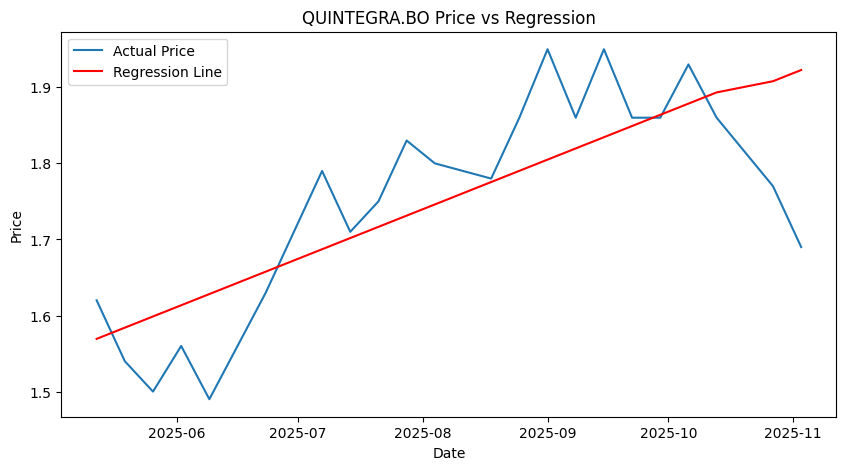

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== QUASAR.BO ===
                            OLS Regression Results                            
Dep. Variable:              QUASAR.BO   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     832.9
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.25e-57
Time:                        10:39:36   Log-Likelihood:                 162.48
No. Observations:                 128   AIC:                            -321.0
Df Residuals:                     126   BIC:                            -315.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8168      0.012 

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['QUANTBUILD.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for QUANTBUILD.BO

=== QUANTDIA.BO ===
                            OLS Regression Results                            
Dep. Variable:            QUANTDIA.BO   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.201
Method:                 Least Squares   F-statistic:                     31.90
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.08e-07
Time:                        10:39:37   Log-Likelihood:                -278.50
No. Observations:                 124   AIC:                             561.0
Df Residuals:                     122   BIC:                             566.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== QNIFTY.BO ===
                            OLS Regression Results                            
Dep. Variable:              QNIFTY.BO   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.347
Method:                 Least Squares   F-statistic:                     67.97
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.94e-13
Time:                        10:39:37   Log-Likelihood:                -637.37
No. Observations:                 127   AIC:                             1279.
Df Residuals:                     125   BIC:                             1284.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2679.4002      6.584 

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['QPRO.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for QPRO.BO

=== QUICKHEAL.BO ===
                            OLS Regression Results                            
Dep. Variable:           QUICKHEAL.BO   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.8519
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.358
Time:                        10:39:38   Log-Likelihood:                -630.29
No. Observations:                 128   AIC:                             1265.
Df Residuals:                     126   BIC:                             1270.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== QGOLDHALF.BO ===
                            OLS Regression Results                            
Dep. Variable:           QGOLDHALF.BO   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     450.2
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.98e-43
Time:                        10:39:38   Log-Likelihood:                -351.96
No. Observations:                 127   AIC:                             707.9
Df Residuals:                     125   BIC:                             713.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         74.0673      0.6

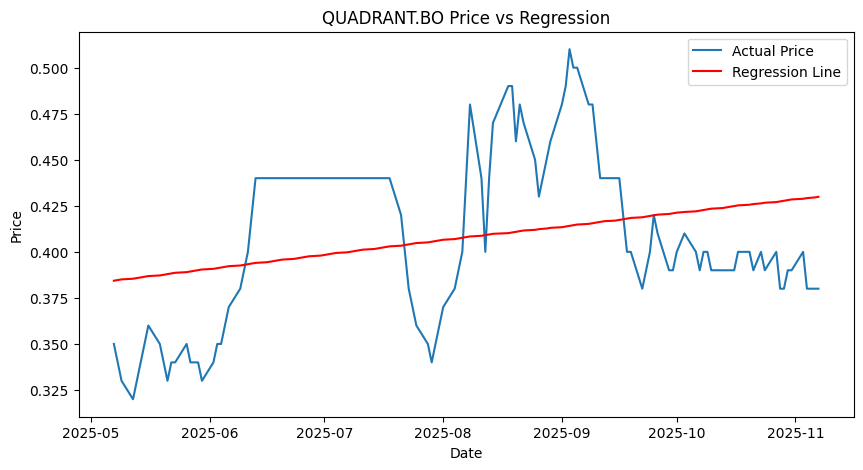

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['QUEST.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for QUEST.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['RUCHISTR.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for RUCHISTR.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['RPIL.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for RPIL.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['RFLINT.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for RFLINT.BO

=== RAPICUT.BO ===
                            OLS Regression Results                            
Dep. Variable:             RAPICUT.BO   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     6.467
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0122
Time:                        10:39:41   Log-Likelihood:                -457.83
No. Observations:                 128   AIC:                             919.7
Df Residuals:                     126   BIC:                             925.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons

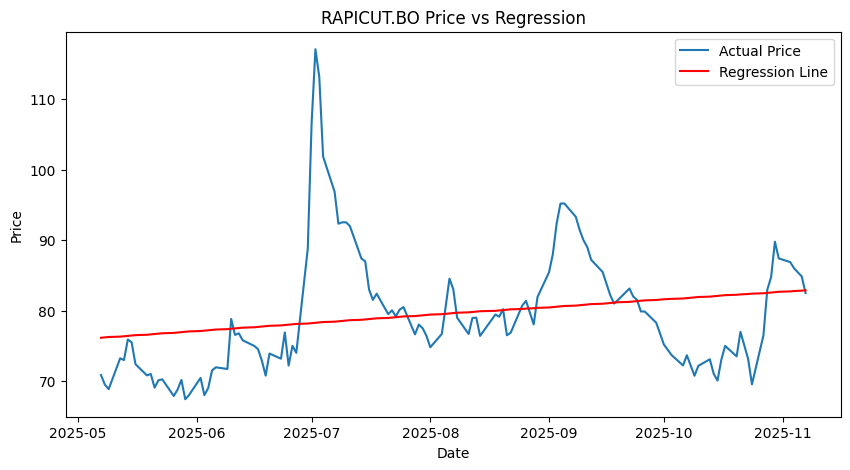

[*********************100%***********************]  1 of 1 completed


=== COARO.BO ===
                            OLS Regression Results                            
Dep. Variable:               COARO.BO   R-squared:                       0.465
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     35.70
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           4.70e-07
Time:                        10:39:41   Log-Likelihood:                -98.239
No. Observations:                  43   AIC:                             200.5
Df Residuals:                      41   BIC:                             204.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         32.9030      0.755  


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


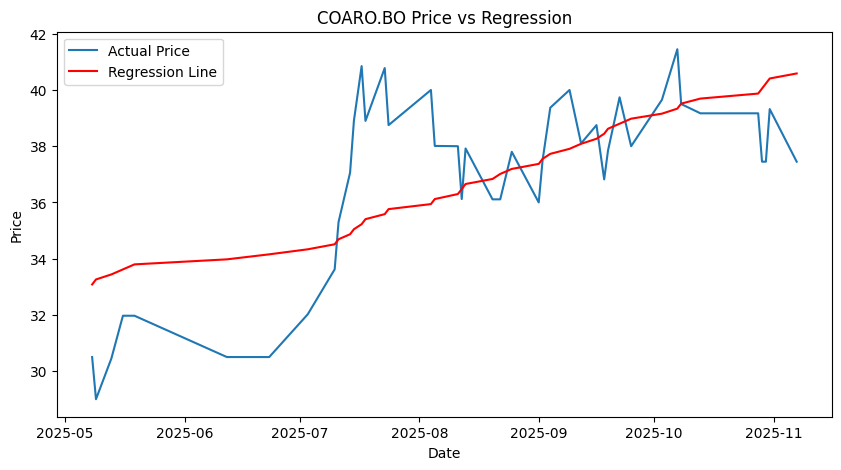

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BSELINFRA.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for BSELINFRA.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SVCRES.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for SVCRES.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== SUNTECK.BO ===
                            OLS Regression Results                            
Dep. Variable:             SUNTECK.BO   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     5.135
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0252
Time:                        10:39:42   Log-Likelihood:                -587.10
No. Observations:                 128   AIC:                             1178.
Df Residuals:                     126   BIC:                             1184.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        414.8730      4.257

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== SHRAJSYNQ.BO ===
                            OLS Regression Results                            
Dep. Variable:           SHRAJSYNQ.BO   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     36.22
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.84e-08
Time:                        10:39:43   Log-Likelihood:                -259.84
No. Observations:                 126   AIC:                             523.7
Df Residuals:                     124   BIC:                             529.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.7877      0.3

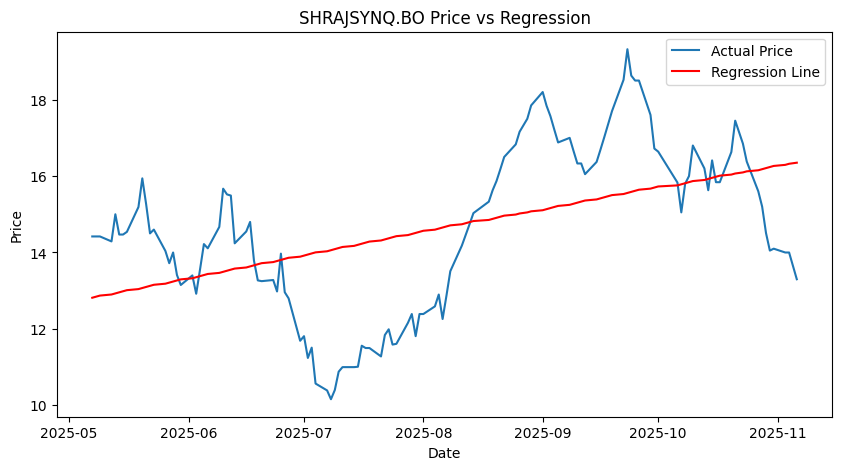

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== SAMKRG.BO ===
                            OLS Regression Results                            
Dep. Variable:              SAMKRG.BO   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.133
Method:                 Least Squares   F-statistic:                     20.47
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.38e-05
Time:                        10:39:43   Log-Likelihood:                -346.36
No. Observations:                 128   AIC:                             696.7
Df Residuals:                     126   BIC:                             702.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        139.1146      0.649 

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['USHDI.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for USHDI.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['UPLBBPH.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


...

No data found for UNIVPRIM.BO

=== UNIVARTS.BO ===
                            OLS Regression Results                            
Dep. Variable:            UNIVARTS.BO   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     6.153
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0144
Time:                        10:39:45   Log-Likelihood:                -19.799
No. Observations:                 128   AIC:                             43.60
Df Residuals:                     126   BIC:                             49.30
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed



=== UNITEDTE.BO ===
                            OLS Regression Results                            
Dep. Variable:            UNITEDTE.BO   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     27.71
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.79e-05
Time:                        10:39:45   Log-Likelihood:                -30.420
No. Observations:                  24   AIC:                             64.84
Df Residuals:                      22   BIC:                             67.20
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.6334      0.37

/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== UNIABEXAL.BO ===
                            OLS Regression Results                            
Dep. Variable:           UNIABEXAL.BO   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     3.270
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0729
Time:                        10:39:46   Log-Likelihood:                -872.49
No. Observations:                 128   AIC:                             1749.
Df Residuals:                     126   BIC:                             1755.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3149.6212     39.5

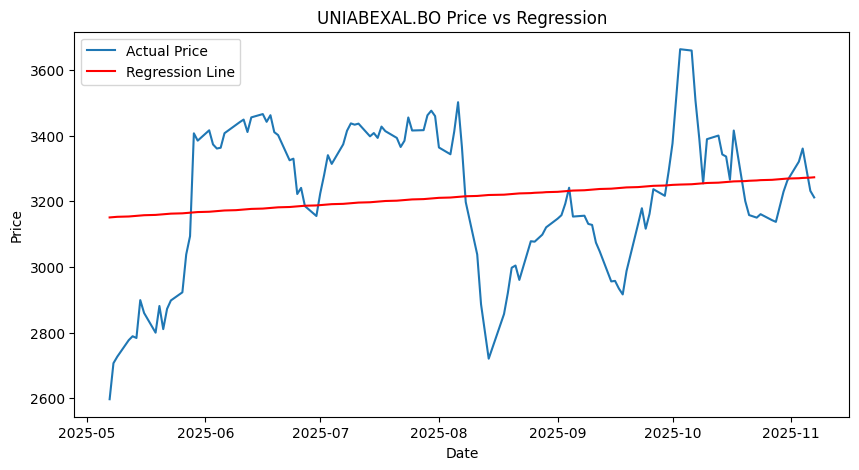

[*********************100%***********************]  1 of 1 completed


=== SINNAR.BO ===
                            OLS Regression Results                            
Dep. Variable:              SINNAR.BO   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     23.49
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           3.60e-06
Time:                        10:39:46   Log-Likelihood:                -758.78
No. Observations:                 129   AIC:                             1522.
Df Residuals:                     127   BIC:                             1527.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        852.5723     15.486 


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


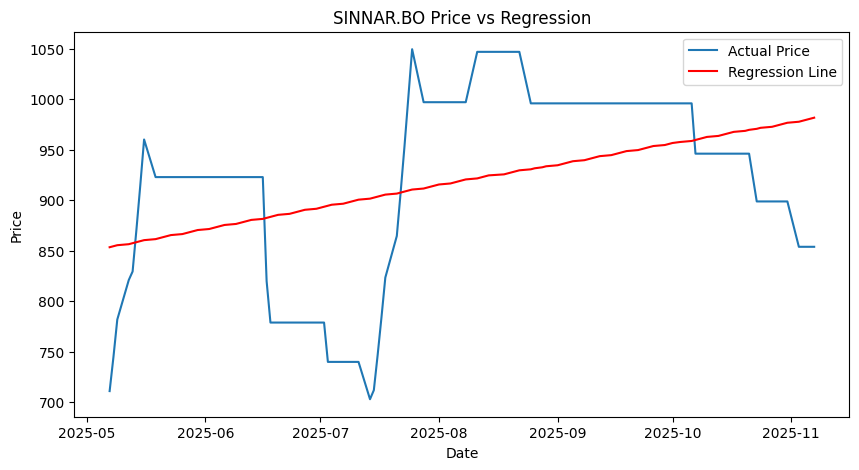

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['VYVRAUT.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo)')



=== CARBORUNIV.BO ===
                            OLS Regression Results                            
Dep. Variable:          CARBORUNIV.BO   R-squared:                       0.257
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     43.55
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.03e-09
Time:                        10:39:46   Log-Likelihood:                -634.32
No. Observations:                 128   AIC:                             1273.
Df Residuals:                     126   BIC:                             1278.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        981.4622      6.

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['VYAPAR.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for VYAPAR.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['VOLTAS6.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for VOLTAS6.BO


[*********************100%***********************]  1 of 1 completed


=== VOLTAS.BO ===
                            OLS Regression Results                            
Dep. Variable:              VOLTAS.BO   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     203.2
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           4.78e-28
Time:                        10:39:48   Log-Likelihood:                -649.89
No. Observations:                 128   AIC:                             1304.
Df Residuals:                     126   BIC:                             1309.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1253.4806      6.953 


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


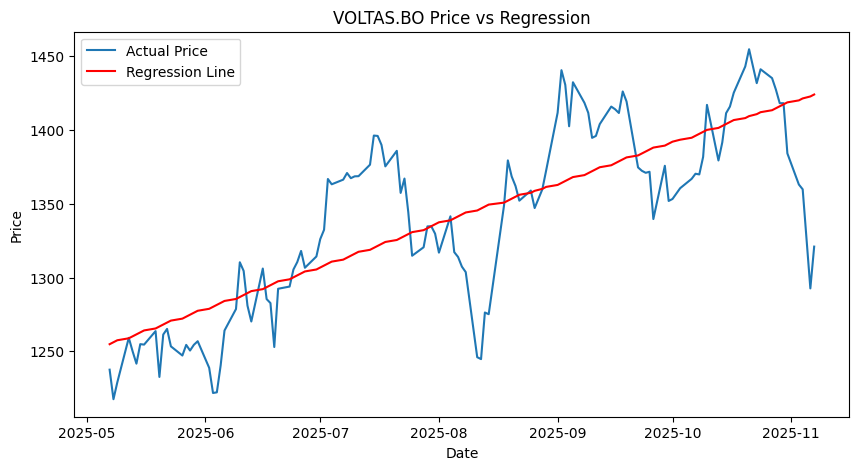

[*********************100%***********************]  1 of 1 completed


=== VIVIDIND.BO ===
                            OLS Regression Results                            
Dep. Variable:            VIVIDIND.BO   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     9.763
Date:                Sun, 09 Nov 2025   Prob (F-statistic):            0.00221
Time:                        10:39:48   Log-Likelihood:                -150.84
No. Observations:                 128   AIC:                             305.7
Df Residuals:                     126   BIC:                             311.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.3006      0.14


/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


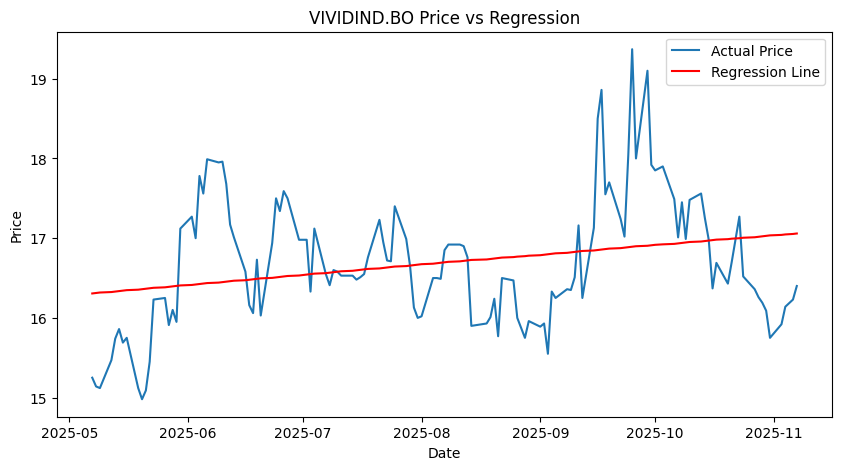

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:



=== VIVIDHA.BO ===
                            OLS Regression Results                            
Dep. Variable:             VIVIDHA.BO   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     103.7
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           3.89e-18
Time:                        10:39:48   Log-Likelihood:                 246.65
No. Observations:                 128   AIC:                            -489.3
Df Residuals:                     126   BIC:                            -483.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8775      0.006

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['VIRTUALS.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])


No data found for VIRTUALS.BO

=== VINYOFL.BO ===
                            OLS Regression Results                            
Dep. Variable:             VINYOFL.BO   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     440.0
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           6.30e-43
Time:                        10:39:49   Log-Likelihood:                -281.77
No. Observations:                 128   AIC:                             567.5
Df Residuals:                     126   BIC:                             573.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a valu

...

No data found for IPRU2296.BO


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['HOTELEELA.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


No data found for HOTELEELA.BO


[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.il


=== GEECEE.BO ===
                            OLS Regression Results                            
Dep. Variable:              GEECEE.BO   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     148.2
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           5.70e-23
Time:                        10:39:54   Log-Likelihood:                -514.32
No. Observations:                 127   AIC:                             1033.
Df Residuals:                     125   BIC:                             1038.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        397.6511      2.499 

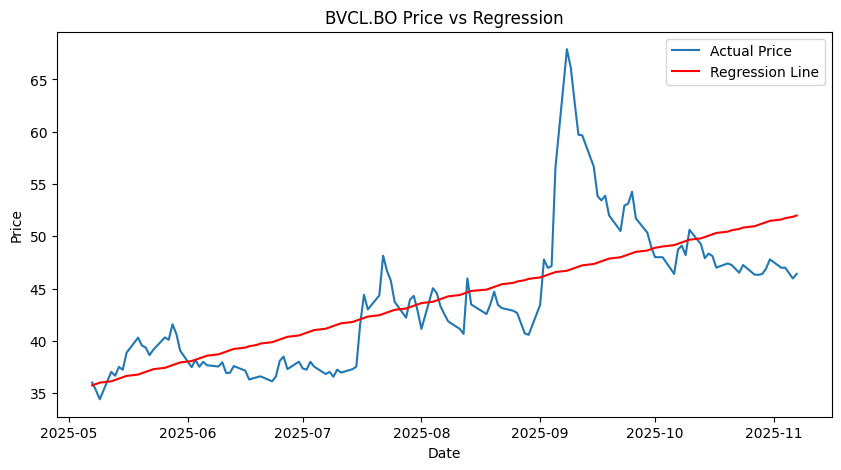

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['VISTR.BO']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')
[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if model.params[1] > 0 and predicted_price > current_price:


No data found for VISTR.BO

=== VLL.BO ===
                            OLS Regression Results                            
Dep. Variable:                 VLL.BO   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     446.8
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           6.81e-41
Time:                        10:39:55   Log-Likelihood:                -288.88
No. Observations:                 114   AIC:                             581.8
Df Residuals:                     112   BIC:                             587.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const    

[*********************100%***********************]  1 of 1 completed
/var/folders/l9/gnmrxnvs68s1zr4fc99zj7b00000gn/T/ipykernel_4986/260957762.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(stock_data['Close'].iloc[-1])



=== SILICON.BO ===


ValueError: resids must contain at least 2 elements

In [40]:
for ticker in tickers:
    analyze_stock(ticker)